In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# # 0) Mount Drive and inspect files (run this first in Colab)
# from google.colab import drive
# drive.mount('/content/drive')

# list top-level of your MyDrive and an example folder listing
!ls -la /content/drive/MyDrive | sed -n '1,200p'

# # If your files are in a subfolder, list that too:
# !ls -la /content/drive/MyDrive/your_data_folder | sed -n '1,200p'

total 1342784
-rw------- 1 root root    152126 Nov  4  2022 021736c9-a939-4fec-b3be-dc0375f9fa63.jpg
-rw------- 1 root root    170997 Nov  4  2022 03ca4b83-248e-4904-bc52-a0df06f1e394.jpg
-rw------- 1 root root    130660 Nov  4  2022 04e9ca9c-e0b5-427b-a3f2-2c5a5a054106.jpg
-rw------- 1 root root    193628 Nov  4  2022 04f908dd-64f3-4730-8959-3637088b0906.jpg
-rw------- 1 root root    113020 Nov  4  2022 053652e5-cb5d-4408-bef2-7e8f59f07fa7.jpg
-rw------- 1 root root     87981 Nov  4  2022 08011dd3-300a-4046-9fa1-8e2c35145718.jpg
-rw------- 1 root root    101114 Nov  4  2022 09ff8d14-0f4c-40d7-8d4b-57b94f81daad.jpg
-rw------- 1 root root     96942 Nov  4  2022 0b598f4b-51ef-40b0-b92f-b1c1d1fc7008.jpg
-rw------- 1 root root    110761 Nov  4  2022 0e2751b1-a4c3-43b2-adfb-4f11d78312b9.jpg
-rw------- 1 root root    102668 Nov  4  2022 0e7e5193-b4f1-4508-891b-4ac5c69e0df6.jpg
-rw------- 1 root root    120481 Nov  4  2022 0e800107-2dba-45ed-8e17-ae023af2beed.jpg
-rw------- 1 root root    163

In [ ]:
import os
import pandas as pd

base_path = '/content/drive/MyDrive/NIFTY50'
output_file = os.path.join(base_path, 'nifty_combined.csv')

all_dfs = []

for file in os.listdir(base_path):
    if file.endswith('.csv') and file != 'nifty_combined.csv':
        file_path = os.path.join(base_path, file)

        # Let pandas handle headers automatically
        df = pd.read_csv(file_path, low_memory=False)

        # Normalize column names (important!)
        df.columns = df.columns.str.strip().str.lower()

        # ---- CLEAN DATE COLUMN ----
        if 'date' in df.columns:
            df['date'] = (
                df['date']
                .astype(str)
                .str.replace('="', '', regex=False)
                .str.replace('"', '', regex=False)
                .str.strip()
            )

            # Convert safely to datetime
            df['date'] = pd.to_datetime(
                df['date'],
                dayfirst=True,
                errors='coerce'   # 🔥 invalid rows become NaT, no crash
            )

        # ---- COMBINE DATE + TIME IF TIME EXISTS ----
        if 'time' in df.columns:
            df['datetime'] = pd.to_datetime(
                df['date'].dt.strftime('%Y-%m-%d') + ' ' + df['time'],
                errors='coerce'
            )

        all_dfs.append(df)

# Combine all files
combined_df = pd.concat(all_dfs, ignore_index=True)

# Sort by datetime if present
if 'datetime' in combined_df.columns:
    combined_df.sort_values(by='datetime', inplace=True)

# Drop duplicates
combined_df.drop_duplicates(inplace=True)

# Save final CSV
combined_df.to_csv(output_file, index=False)

print(f"✅ Combined CSV saved to: {output_file}")
print(f"📊 Total rows: {len(combined_df)}")


/tmp/ipython-input-1738084053.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(
/tmp/ipython-input-1738084053.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(
/tmp/ipython-input-1738084053.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(
/tmp/ipython-input-1738084053.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_da

✅ Combined CSV saved to: /content/drive/MyDrive/NIFTY50/nifty_combined.csv
📊 Total rows: 5009439


In [ ]:
import os
import re
import pandas as pd

base_path = '/content/drive/MyDrive/FINNIFTY'
output_file = os.path.join(base_path, 'finnifty_combined.csv')

all_dfs = []

for file in os.listdir(base_path):
    if not file.endswith('.csv') or file == 'finnifty_combined.csv':
        continue

    file_path = os.path.join(base_path, file)

    # Auto-detect delimiter (comma / tab)
    df = pd.read_csv(file_path, sep=None, engine='python')
    df.columns = df.columns.str.strip().str.lower()

    # ---- FIX DATE PROPERLY ----
    if 'date' in df.columns:
        # Clean date strings
        df['date'] = df['date'].astype(str).str.strip()

        # If date column is EMPTY → fill from filename
        if df['date'].replace('', pd.NA).isna().all():
            match = re.search(r'\d{2}-\d{2}-\d{2}', file)
            if not match:
                print(f"⚠️ Date not found anywhere for file: {file}")
                continue

            file_date = pd.to_datetime(match.group(), format='%d-%m-%y')
            df['date'] = file_date
        else:
            # Parse existing date column
            df['date'] = pd.to_datetime(
                df['date'],
                format='%d-%m-%y',
                errors='coerce'
            )
    else:
        print(f"⚠️ No date column in file: {file}")
        continue

    # ---- BUILD DATETIME ----
    if 'time' not in df.columns:
        print(f"⚠️ No time column in file: {file}")
        continue

    df['datetime'] = pd.to_datetime(
        df['date'].dt.strftime('%Y-%m-%d') + ' ' + df['time'],
        errors='coerce'
    )

    all_dfs.append(df)

# Combine all files
combined_df = pd.concat(all_dfs, ignore_index=True)

# Sort correctly
combined_df.sort_values(by='datetime', inplace=True)

# Drop duplicates
combined_df.drop_duplicates(inplace=True)

# Save
combined_df.to_csv(output_file, index=False)

print(f"✅ FINNIFTY combined CSV saved to: {output_file}")
print(f"📊 Total rows: {len(combined_df)}")


✅ FINNIFTY combined CSV saved to: /content/drive/MyDrive/FINNIFTY/finnifty_combined.csv
📊 Total rows: 403768



ALGORITHMIC TRADING SYSTEM - EDA & FEATURE ENGINEERING


>>> Loading FINNIFTY data...
Found 17 FINNIFTY files

EXPLORATORY DATA ANALYSIS - FINNIFTY

1. DATASET OVERVIEW
--------------------------------------------------------------------------------
Total Records: 404,367
Date Range: 2021-08-04 10:00:00 to 2026-01-27 18:36:00
Duration: 1637 days

Columns: ['date', 'time', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'datetime']

Data Types:
date                object
time                object
symbol              object
open               float64
high               float64
low                float64
close              float64
volume             float64
datetime    datetime64[ns]
dtype: object

Missing Values:
date        0
time        0
symbol      0
open        0
high        0
low         0
close       0
volume      0
datetime    0
dtype: int64

2. STATISTICAL SUMMARY
--------------------------------------------------------------------------------
                open         

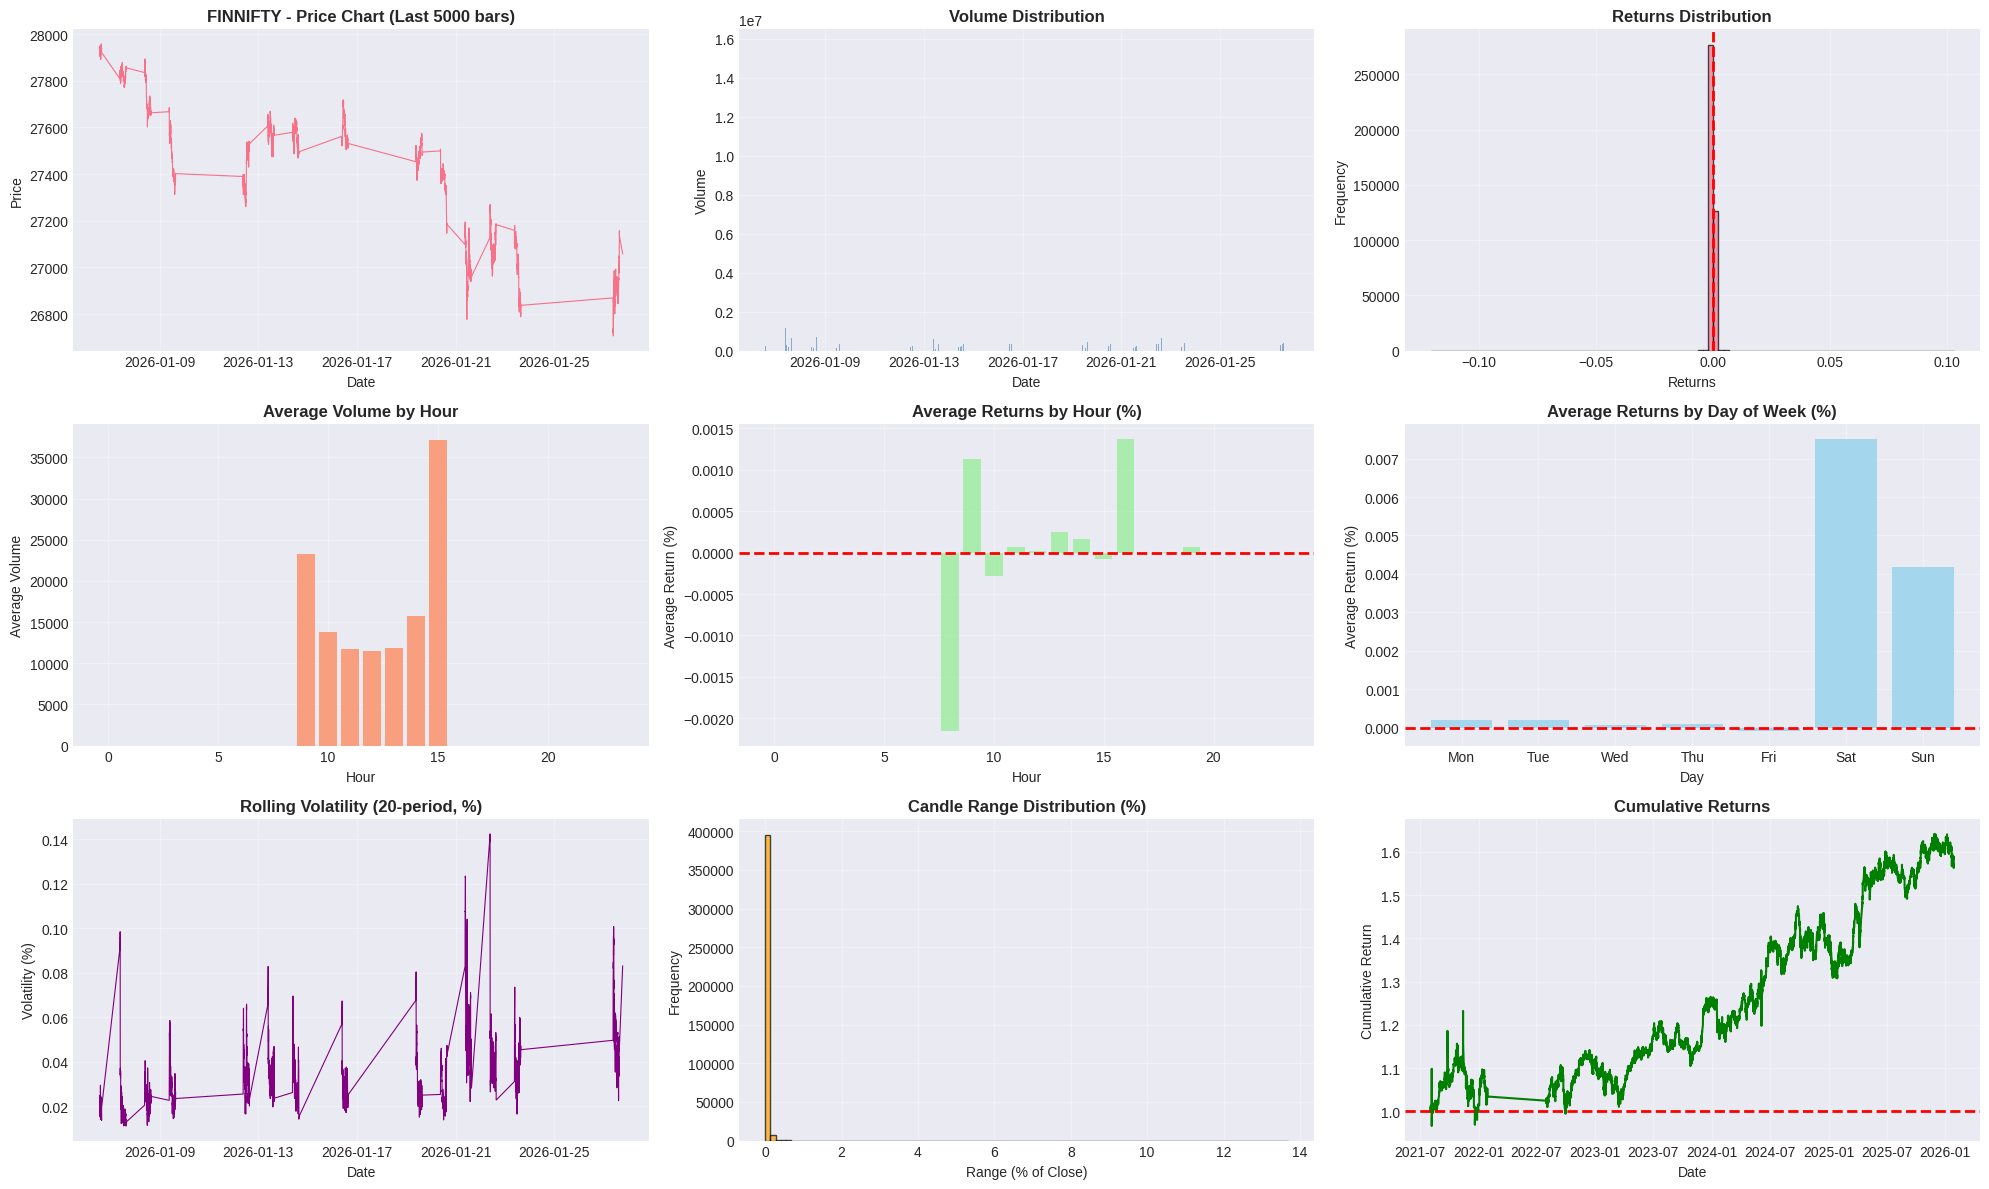

Engineering ML features...
Feature engineering complete. Total features: 101

ML Dataset prepared:
Features: 37
Samples: 21,765
Positive signals: 0 (0.00%)
Target distribution: {1: 10915, 0: 10850}

FINNIFTY processed data saved!

>>> Loading NIFTY50 data...
Found 0 NIFTY files


ValueError: No objects to concatenate

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#=============================================================================
# PART 1: DATA LOADING AND PREPROCESSING
#=============================================================================

def load_finnifty_data(base_path='/content/drive/MyDrive/FINNIFTY'):
    """Load all FINNIFTY CSV files"""
    import glob

    all_files = sorted(glob.glob(f"{base_path}/*.csv"))
    print(f"Found {len(all_files)} FINNIFTY files")

    dfs = []
    for file in all_files:
        df = pd.read_csv(file)
        # Clean date format (remove Excel formula artifacts)
        df['date'] = df['date'].str.replace('="', '').str.replace('"', '')
        dfs.append(df)

    # Combine all data
    combined_df = pd.concat(dfs, ignore_index=True)

    # Parse datetime
    combined_df['datetime'] = pd.to_datetime(
        combined_df['date'] + ' ' + combined_df['time'],
        format='%d-%m-%y %H:%M:%S'
    )
    combined_df = combined_df.sort_values('datetime').reset_index(drop=True)

    return combined_df, all_files

def load_nifty_data(base_path='/content/drive/MyDrive/NIFTY50'):
    """Load all NIFTY Excel files"""
    import glob

    all_files = sorted(glob.glob(f"{base_path}/*.xlsx"))
    print(f"Found {len(all_files)} NIFTY files")

    if not all_files:
        print(f"Warning: No NIFTY Excel files found in {base_path}. Returning empty DataFrame for NIFTY50.")
        # Return an empty DataFrame with required columns to prevent downstream errors
        # These columns are inferred from subsequent usage in the script
        empty_df = pd.DataFrame(columns=['date', 'time', 'open', 'high', 'low', 'close', 'volume', 'symbol', 'option_type', 'spot'])
        empty_df['datetime'] = pd.to_datetime([]) # Ensure datetime column is of datetime type
        return empty_df, []

    dfs = []
    for file in all_files:
        df = pd.read_excel(file)
        dfs.append(df)

    # Combine all data
    combined_df = pd.concat(dfs, ignore_index=True)

    # Parse datetime (time is in fraction of day format)
    combined_df['datetime'] = pd.to_datetime(combined_df['date'], format='%d-%m-%y')
    combined_df['datetime'] = combined_df['datetime'] + pd.to_timedelta(combined_df['time'], unit='D')
    combined_df = combined_df.sort_values('datetime').reset_index(drop=True)

    return combined_df, all_files

#=============================================================================
# PART 2: EXPLORATORY DATA ANALYSIS
#=============================================================================

def perform_eda(df, index_name='INDEX'):
    """Comprehensive EDA on trading data"""

    print(f"\n{'='*80}")
    print(f"EXPLORATORY DATA ANALYSIS - {index_name}")
    print(f"{'='*80}\n")

    # Basic Information
    print("1. DATASET OVERVIEW")
    print("-" * 80)
    print(f"Total Records: {len(df):,}")
    print(f"Date Range: {df['datetime'].min()} to {df['datetime'].max()}")
    print(f"Duration: {(df['datetime'].max() - df['datetime'].min()).days} days")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nData Types:\n{df.dtypes}")
    print(f"\nMissing Values:\n{df.isnull().sum()}")

    # Statistical Summary
    print("\n2. STATISTICAL SUMMARY")
    print("-" * 80)
    print(df[['open', 'high', 'low', 'close', 'volume']].describe())

    # Price Analysis
    print("\n3. PRICE ANALYSIS")
    print("-" * 80)
    df['returns'] = df['close'].pct_change()
    df['log_returns'] = np.log(df['close'] / df['close'].shift(1))

    print(f"Average Daily Return: {df['returns'].mean()*100:.4f}%")
    print(f"Volatility (Std Dev): {df['returns'].std()*100:.4f}%")
    print(f"Min Return: {df['returns'].min()*100:.4f}%")
    print(f"Max Return: {df['returns'].max()*100:.4f}%")
    print(f"Sharpe Ratio (approx): {(df['returns'].mean() / df['returns'].std()) * np.sqrt(252):.4f}")

    # Volume Analysis
    print("\n4. VOLUME ANALYSIS")
    print("-" * 80)
    print(f"Average Volume: {df['volume'].mean():,.0f}")
    print(f"Max Volume: {df['volume'].max():,.0f}")
    print(f"Min Volume: {df['volume'].min():,.0f}")
    print(f"Volume Std Dev: {df['volume'].std():,.0f}")

    # Intraday Patterns
    df['hour'] = df['datetime'].dt.hour
    df['minute'] = df['datetime'].dt.minute
    df['day_of_week'] = df['datetime'].dt.dayofweek

    print("\n5. INTRADAY PATTERNS")
    print("-" * 80)
    hourly_volume = df.groupby('hour')['volume'].mean()
    print("Average Volume by Hour:")
    print(hourly_volume)

    return df

def visualize_data(df, index_name='INDEX'):
    """Create comprehensive visualizations"""

    fig = plt.figure(figsize=(20, 12))

    # Ensure 'returns' and 'rolling_vol' are calculated on df BEFORE df_sample is created
    df['returns'] = df['close'].pct_change()
    df['rolling_vol'] = df['returns'].rolling(window=20).std() * 100

    df_sample = df.iloc[-5000:]  # Last 5000 candles for visibility

    # 1. Price Chart with Volume
    ax1 = plt.subplot(3, 3, 1)
    ax1.plot(df_sample['datetime'], df_sample['close'], linewidth=0.8)
    ax1.set_title(f'{index_name} - Price Chart (Last 5000 bars)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price')
    ax1.grid(True, alpha=0.3)

    # 2. Volume Chart
    ax2 = plt.subplot(3, 3, 2)
    ax2.bar(df_sample['datetime'], df_sample['volume'], width=0.0003, color='steelblue', alpha=0.6)
    ax2.set_title('Volume Distribution', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Volume')
    ax2.grid(True, alpha=0.3)

    # 3. Returns Distribution
    ax3 = plt.subplot(3, 3, 3)
    ax3.hist(df['returns'].dropna(), bins=100, edgecolor='black', alpha=0.7)
    ax3.set_title('Returns Distribution', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Returns')
    ax3.set_ylabel('Frequency')
    ax3.axvline(0, color='red', linestyle='--', linewidth=2)
    ax3.grid(True, alpha=0.3)

    # 4. Hourly Volume Pattern
    ax4 = plt.subplot(3, 3, 4)
    hourly_vol = df.groupby('hour')['volume'].mean()
    ax4.bar(hourly_vol.index, hourly_vol.values, color='coral', alpha=0.7)
    ax4.set_title('Average Volume by Hour', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Hour')
    ax4.set_ylabel('Average Volume')
    ax4.grid(True, alpha=0.3)

    # 5. Hourly Returns Pattern
    ax5 = plt.subplot(3, 3, 5)
    hourly_ret = df.groupby('hour')['returns'].mean() * 100
    ax5.bar(hourly_ret.index, hourly_ret.values, color='lightgreen', alpha=0.7)
    ax5.set_title('Average Returns by Hour (%)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Hour')
    ax5.set_ylabel('Average Return (%)')
    ax5.axhline(0, color='red', linestyle='--', linewidth=2)
    ax5.grid(True, alpha=0.3)

    # 6. Day of Week Pattern
    ax6 = plt.subplot(3, 3, 6)
    dow_ret = df.groupby('day_of_week')['returns'].mean() * 100
    # Define labels for all 7 days (Monday=0, Sunday=6)
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    ax6.bar(dow_ret.index, dow_ret.values, color='skyblue', alpha=0.7)
    ax6.set_xticks(dow_ret.index)
    ax6.set_xticklabels([days[i] for i in dow_ret.index])
    ax6.set_title('Average Returns by Day of Week (%)', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Day')
    ax6.set_ylabel('Average Return (%)')
    ax6.axhline(0, color='red', linestyle='--', linewidth=2)
    ax6.grid(True, alpha=0.3)

    # 7. Volatility Over Time (Rolling 20-period)
    ax7 = plt.subplot(3, 3, 7)
    ax7.plot(df_sample['datetime'], df_sample['rolling_vol'], color='purple', linewidth=0.8)
    ax7.set_title('Rolling Volatility (20-period, %)', fontsize=12, fontweight='bold')
    ax7.set_xlabel('Date')
    ax7.set_ylabel('Volatility (%)')
    ax7.grid(True, alpha=0.3)

    # 8. Candlestick Range Distribution
    ax8 = plt.subplot(3, 3, 8)
    df['candle_range'] = ((df['high'] - df['low']) / df['close']) * 100
    ax8.hist(df['candle_range'].dropna(), bins=100, edgecolor='black', alpha=0.7, color='orange')
    ax8.set_title('Candle Range Distribution (%)', fontsize=12, fontweight='bold')
    ax8.set_xlabel('Range (% of Close)')
    ax8.set_ylabel('Frequency')
    ax8.grid(True, alpha=0.3)

    # 9. Cumulative Returns
    ax9 = plt.subplot(3, 3, 9)
    df['cumulative_returns'] = (1 + df['returns']).cumprod()
    ax9.plot(df['datetime'], df['cumulative_returns'], color='green', linewidth=1.5)
    ax9.set_title('Cumulative Returns', fontsize=12, fontweight='bold')
    ax9.set_xlabel('Date')
    ax9.set_ylabel('Cumulative Return')
    ax9.axhline(1, color='red', linestyle='--', linewidth=2)
    ax9.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{index_name}_eda_analysis.png', dpi=150, bbox_inches='tight')
    print(f"\nVisualization saved as '{index_name}_eda_analysis.png'")
    plt.show()

#=============================================================================
# PART 3: STRUCTURE IDENTIFICATION FEATURES
#=============================================================================

def calculate_market_structure(df):
    """
    Identify market structure: Higher Highs, Higher Lows, Lower Highs, Lower Lows
    Essential for structure-based trading
    """
    df = df.copy()

    # Find swing highs and lows (simple method using rolling windows)
    window = 10
    df['swing_high'] = df['high'] == df['high'].rolling(window=window*2+1, center=True).max()
    df['swing_low'] = df['low'] == df['low'].rolling(window=window*2+1, center=True).min()

    # Identify trend structure
    df['structure'] = 'NEUTRAL'

    return df

def calculate_fibonacci_levels(df, lookback=100):
    """
    Calculate Fibonacci retracement levels
    OTE zone: 0.5 - 0.618 (50% - 61.8% retracement)
    """
    df = df.copy()

    # Calculate swing high and low over lookback period
    df['swing_high_price'] = df['high'].rolling(window=lookback).max()
    df['swing_low_price'] = df['low'].rolling(window=lookback).min()

    # Calculate Fibonacci levels
    df['fib_range'] = df['swing_high_price'] - df['swing_low_price']
    df['fib_0.236'] = df['swing_high_price'] - 0.236 * df['fib_range']
    df['fib_0.382'] = df['swing_high_price'] - 0.382 * df['fib_range']
    df['fib_0.500'] = df['swing_high_price'] - 0.500 * df['fib_range']
    df['fib_0.618'] = df['swing_high_price'] - 0.618 * df['fib_range']
    df['fib_0.786'] = df['swing_high_price'] - 0.786 * df['fib_range']

    # Flag if price is in OTE zone (0.5 - 0.618)
    df['in_ote_zone'] = (
        (df['close'] >= df['fib_0.618']) &
        (df['close'] <= df['fib_0.500'])
    )

    return df

def identify_fvg(df, min_gap_pct=0.1):
    """
    Identify Fair Value Gaps (FVG)
    FVG = gap between candle 1's high and candle 3's low (bullish)
    or gap between candle 1's low and candle 3's high (bearish)
    """
    df = df.copy()

    # Bullish FVG: gap up (candle 1 high < candle 3 low)
    df['bullish_fvg'] = (
        (df['low'].shift(-2) - df['high']) / df['close'] > min_gap_pct/100
    )

    # Bearish FVG: gap down (candle 1 low > candle 3 high)
    df['bearish_fvg'] = (
        (df['low'] - df['high'].shift(-2)) / df['close'] > min_gap_pct/100
    )

    # Store FVG zones
    df['fvg_high'] = np.where(df['bullish_fvg'], df['low'].shift(-2),
                              np.where(df['bearish_fvg'], df['low'], np.nan))
    df['fvg_low'] = np.where(df['bullish_fvg'], df['high'],
                             np.where(df['bearish_fvg'], df['high'].shift(-2), np.nan))

    # Check if current price is in FVG zone
    df['in_fvg'] = (
        ((df['close'] >= df['fvg_low'].shift(1)) & (df['close'] <= df['fvg_high'].shift(1))) |
        ((df['close'] >= df['fvg_low'].shift(2)) & (df['close'] <= df['fvg_high'].shift(2)))
    )

    return df

def identify_order_blocks(df, lookback=20):
    """
    Identify Order Blocks
    Bullish OB: Last down candle before strong up move
    Bearish OB: Last up candle before strong down move
    """
    df = df.copy()

    # Calculate candle direction
    df['is_bullish'] = df['close'] > df['open']
    df['is_bearish'] = df['close'] < df['open']

    # Calculate price change
    df['price_change_pct'] = df['close'].pct_change() * 100

    # Bullish Order Block: bearish candle followed by strong bullish move
    df['strong_up_move'] = (
        (df['price_change_pct'].shift(-1) > 1) |  # Next candle strong up
        (df['close'].shift(-5) > df['close'] * 1.02)  # Price up 2% in next 5 candles
    )
    df['bullish_ob'] = df['is_bearish'] & df['strong_up_move']

    # Bearish Order Block: bullish candle followed by strong bearish move
    df['strong_down_move'] = (
        (df['price_change_pct'].shift(-1) < -1) |  # Next candle strong down
        (df['close'].shift(-5) < df['close'] * 0.98)  # Price down 2% in next 5 candles
    )
    df['bearish_ob'] = df['is_bullish'] & df['strong_down_move']

    # Store OB zones
    df['bullish_ob_high'] = np.where(df['bullish_ob'], df['high'], np.nan)
    df['bullish_ob_low'] = np.where(df['bullish_ob'], df['low'], np.nan)
    df['bearish_ob_high'] = np.where(df['bearish_ob'], df['high'], np.nan)
    df['bearish_ob_low'] = np.where(df['bearish_ob'], df['low'], np.nan)

    # Check if current price is in OB zone
    df['in_bullish_ob'] = False
    df['in_bearish_ob'] = False

    for i in range(lookback):
        df['in_bullish_ob'] |= (
            (df['close'] >= df['bullish_ob_low'].shift(i)) &
            (df['close'] <= df['bullish_ob_high'].shift(i))
        )
        df['in_bearish_ob'] |= (
            (df['close'] >= df['bearish_ob_low'].shift(i)) &
            (df['close'] <= df['bearish_ob_high'].shift(i))
        )

    return df

def calculate_order_flow(df, window=20):
    """
    Calculate Order Flow indicators
    Using volume and price action
    """
    df = df.copy()

    # Volume-weighted price change
    df['volume_delta'] = df['volume'] * np.sign(df['close'] - df['open'])
    df['cumulative_volume_delta'] = df['volume_delta'].rolling(window=window).sum()

    # Buying vs Selling pressure
    df['buying_pressure'] = np.where(df['close'] > df['open'], df['volume'], 0)
    df['selling_pressure'] = np.where(df['close'] < df['open'], df['volume'], 0)
    df['order_flow_ratio'] = (
        df['buying_pressure'].rolling(window=window).sum() /
        (df['selling_pressure'].rolling(window=window).sum() + 1)
    )

    # Bullish order flow: ratio > 1.5
    df['bullish_order_flow'] = df['order_flow_ratio'] > 1.5
    df['bearish_order_flow'] = df['order_flow_ratio'] < 0.67

    return df

def detect_overstretched_move(df, lookback=14, threshold=2):
    """
    Detect overstretched moves to avoid entering
    Using multiple methods: RSI, Bollinger Bands distance, ATR multiplier
    """
    df = df.copy()

    # RSI
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=lookback).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=lookback).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))

    # Bollinger Bands
    df['bb_middle'] = df['close'].rolling(window=lookback).mean()
    df['bb_std'] = df['close'].rolling(window=lookback).std()
    df['bb_upper'] = df['bb_middle'] + (threshold * df['bb_std'])
    df['bb_lower'] = df['bb_middle'] - (threshold * df['bb_std'])

    # ATR
    df['tr'] = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            abs(df['high'] - df['close'].shift(1)),
            abs(df['low'] - df['close'].shift(1))
        )
    )
    df['atr'] = df['tr'].rolling(window=lookback).mean()

    # Price distance from moving average in ATR units
    df['ma'] = df['close'].rolling(window=lookback).mean()
    df['price_distance_atr'] = abs(df['close'] - df['ma']) / df['atr']

    # Flag overstretched conditions
    df['overstretched'] = (
        (df['rsi'] > 70) | (df['rsi'] < 30) |  # Overbought/Oversold
        (df['close'] > df['bb_upper']) | (df['close'] < df['bb_lower']) |  # Outside BBands
        (df['price_distance_atr'] > 2.5)  # Too far from MA
    )

    return df

def calculate_chandelier_exit(df, period=22, multiplier=3):
    """
    Calculate Chandelier Exit for trailing stop loss
    Long: Highest High - (ATR * multiplier)
    Short: Lowest Low + (ATR * multiplier)
    """
    df = df.copy()

    # ATR calculation
    df['tr'] = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            abs(df['high'] - df['close'].shift(1)),
            abs(df['low'] - df['close'].shift(1))
        )
    )
    df['atr'] = df['tr'].rolling(window=period).mean()

    # Chandelier Exit levels
    df['highest_high'] = df['high'].rolling(window=period).max()
    df['lowest_low'] = df['low'].rolling(window=period).min()

    df['chandelier_long_exit'] = df['highest_high'] - (multiplier * df['atr'])
    df['chandelier_short_exit'] = df['lowest_low'] + (multiplier * df['atr'])

    return df

#=============================================================================
# PART 4: FEATURE ENGINEERING FOR ML
#=============================================================================

def engineer_ml_features(df):
    """
    Create comprehensive features for machine learning
    """
    df = df.copy()

    print("Engineering ML features...")

    # Apply all structure-based features
    df = calculate_fibonacci_levels(df, lookback=100)
    df = identify_fvg(df, min_gap_pct=0.1)
    df = identify_order_blocks(df, lookback=20)
    df = calculate_order_flow(df, window=20)
    df = detect_overstretched_move(df, lookback=14, threshold=2)
    df = calculate_chandelier_exit(df, period=22, multiplier=3)

    # Additional technical indicators
    for period in [5, 10, 20, 50]:
        df[f'sma_{period}'] = df['close'].rolling(window=period).mean()
        df[f'ema_{period}'] = df['close'].ewm(span=period, adjust=False).mean()

    # Price position relative to moving averages
    df['price_above_sma20'] = (df['close'] > df['sma_20']).astype(int)
    df['price_above_sma50'] = (df['close'] > df['sma_50']).astype(int)

    # Momentum indicators
    df['roc_10'] = ((df['close'] - df['close'].shift(10)) / df['close'].shift(10)) * 100
    df['roc_20'] = ((df['close'] - df['close'].shift(20)) / df['close'].shift(20)) * 100

    # Volume features
    df['volume_sma20'] = df['volume'].rolling(window=20).mean()
    df['volume_ratio'] = df['volume'] / df['volume_sma20']

    # Time-based features
    df['hour'] = df['datetime'].dt.hour
    df['minute'] = df['datetime'].dt.minute
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['day_of_month'] = df['datetime'].dt.day

    # Lag features
    for lag in [1, 2, 3, 5, 10]:
        df[f'close_lag_{lag}'] = df['close'].shift(lag)
        df[f'volume_lag_{lag}'] = df['volume'].shift(lag)
        df[f'returns_lag_{lag}'] = df['returns'].shift(lag)

    # Target variable: Future returns
    for horizon in [1, 5, 10]:
        df[f'future_return_{horizon}'] = df['close'].shift(-horizon) / df['close'] - 1
        df[f'future_direction_{horizon}'] = (df[f'future_return_{horizon}'] > 0).astype(int)

    print(f"Feature engineering complete. Total features: {len(df.columns)}")

    return df

def prepare_ml_dataset(df, target_horizon=5):
    """
    Prepare dataset for machine learning
    """
    # Create entry signal based on structure confluence
    df['trade_signal'] = (
        df['in_ote_zone'] &
        (df['in_fvg'] | df['in_bullish_ob'] | df['in_bearish_ob']) &
        df['bullish_order_flow'] &
        ~df['overstretched']
    ).astype(int)

    # Feature columns
    feature_cols = [
        # Fibonacci
        'fib_0.500', 'fib_0.618', 'in_ote_zone',
        # FVG
        'in_fvg', 'bullish_fvg', 'bearish_fvg',
        # Order Blocks
        'in_bullish_ob', 'in_bearish_ob',
        # Order Flow
        'order_flow_ratio', 'bullish_order_flow', 'bearish_order_flow',
        # Overstretched
        'rsi', 'price_distance_atr', 'overstretched',
        # Moving Averages
        'sma_5', 'sma_10', 'sma_20', 'sma_50',
        'ema_5', 'ema_10', 'ema_20', 'ema_50',
        'price_above_sma20', 'price_above_sma50',
        # Momentum
        'roc_10', 'roc_20',
        # Volume
        'volume_ratio',
        # Time
        'hour', 'day_of_week',
        # Lags
        'returns_lag_1', 'returns_lag_2', 'returns_lag_3',
        'volume_lag_1', 'volume_lag_2',
        # Chandelier
        'chandelier_long_exit', 'chandelier_short_exit',
        # ATR
        'atr'
    ]

    # Target
    target_col = f'future_direction_{target_horizon}'

    # Remove rows with NaN
    df_clean = df[feature_cols + [target_col, 'trade_signal', 'datetime']].dropna()

    X = df_clean[feature_cols]
    y = df_clean[target_col]
    signals = df_clean['trade_signal']
    dates = df_clean['datetime']

    print(f"\nML Dataset prepared:")
    print(f"Features: {X.shape[1]}")
    print(f"Samples: {X.shape[0]:,}")
    print(f"Positive signals: {signals.sum():,} ({signals.sum()/len(signals)*100:.2f}%)")
    print(f"Target distribution: {y.value_counts().to_dict()}")

    return X, y, signals, dates, feature_cols

#=============================================================================
# MAIN EXECUTION
#=============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("ALGORITHMIC TRADING SYSTEM - EDA & FEATURE ENGINEERING")
    print("="*80 + "\n")

    # =========================================================================
    # LOAD FINNIFTY DATA
    # =========================================================================
    print("\n>>> Loading FINNIFTY data...")
    finnifty_df, finnifty_files = load_finnifty_data()

    # Perform EDA
    finnifty_df = perform_eda(finnifty_df, 'FINNIFTY')
    visualize_data(finnifty_df, 'FINNIFTY')

    # Engineer features
    finnifty_df = engineer_ml_features(finnifty_df)

    # Prepare ML dataset
    X_finn, y_finn, signals_finn, dates_finn, features = prepare_ml_dataset(
        finnifty_df, target_horizon=5
    )

    # Save processed data
    finnifty_df.to_pickle('/content/drive/MyDrive/finnifty_processed.pkl')
    print("\nFINNIFTY processed data saved!")

    # =========================================================================
    # LOAD NIFTY DATA
    # =========================================================================
    print("\n>>> Loading NIFTY50 data...")
    nifty_df, nifty_files = load_nifty_data()

    if nifty_df.empty:
        print("\nSkipping NIFTY50 EDA and feature engineering due to no data found.")
    else:
        # Perform EDA
        nifty_df = perform_eda(nifty_df, 'NIFTY50')

        # For NIFTY, we need to aggregate to get OHLCV if it's options data
        if 'option_type' in nifty_df.columns:
            print("\nDetected options data. Aggregating to underlying spot prices...")
            nifty_spot = nifty_df.groupby('datetime').agg({
                'spot': 'last',
                'volume': 'sum'
            }).reset_index()
            nifty_spot.columns = ['datetime', 'close', 'volume']

            # Create OHLC from spot prices
            nifty_spot = nifty_spot.sort_values('datetime')
            nifty_spot['open'] = nifty_spot['close']
            nifty_spot['high'] = nifty_spot['close']
            nifty_spot['low'] = nifty_spot['close']

            nifty_df = nifty_spot

        visualize_data(nifty_df, 'NIFTY50')

        # Engineer features
        nifty_df = engineer_ml_features(nifty_df)

        # Prepare ML dataset
        X_nifty, y_nifty, signals_nifty, dates_nifty, features = prepare_ml_dataset(
            nifty_df, target_horizon=5
        )

        # Save processed data
        nifty_df.to_pickle('/content/drive/MyDrive/nifty_processed.pkl')
        print("\nNIFTY50 processed data saved!")

    print("\n" + "="*80)
    print("EDA AND FEATURE ENGINEERING COMPLETE!")
    print("="*80)
    print("\nNext steps:")
    print("1. Review the generated visualizations")
    print("2. Analyze feature importance")
    print("3. Train ML models (Random Forest, XGBoost, LSTM)")
    print("4. Backtest on hold-out data")
    print("5. Optimize hyperparameters")

In [ ]:
"""
FINNIFTY Algorithmic Trading System
Structure-based Trading with OTE (50% Fibonacci) + FVG + Market Regime Classification
ML Model: XGBoost
Exit Strategy: Chandelier Stop

Author: Trading System
Date: January 2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, time
import warnings
import glob
import pickle
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#=============================================================================
# PART 1: DATA LOADING AND PREPROCESSING
#=============================================================================

class DataLoader:
    """Load and preprocess FINNIFTY data"""

    def __init__(self, base_path='/content/drive/MyDrive/FINNIFTY'):
        self.base_path = base_path

    def load_data(self, file_indices=None):
        """
        Load FINNIFTY CSV files

        Parameters:
        -----------
        file_indices : list or None
            Specific file indices to load (e.g., [0,1,2] for first 3 files)
            If None, loads all files
        """
        all_files = sorted(glob.glob(f"{self.base_path}/*.csv"))

        if file_indices is not None:
            all_files = [all_files[i] for i in file_indices if i < len(all_files)]

        print(f"Loading {len(all_files)} FINNIFTY files...")

        dfs = []
        for file in tqdm(all_files):
            df = pd.read_csv(file)
            # Clean date format (remove Excel formula artifacts)
            df['date'] = df['date'].astype(str).str.replace('="', '').str.replace('"', '')
            dfs.append(df)

        # Combine all data
        combined_df = pd.concat(dfs, ignore_index=True)

        # Parse datetime
        combined_df['datetime'] = pd.to_datetime(
            combined_df['date'] + ' ' + combined_df['time'],
            format='%d-%m-%y %H:%M:%S',
            errors='coerce'
        )

        # Remove any rows with invalid datetime
        combined_df = combined_df.dropna(subset=['datetime'])

        # Sort by datetime
        combined_df = combined_df.sort_values('datetime').reset_index(drop=True)

        # Filter market hours only (9:15 AM - 3:30 PM)
        combined_df['hour'] = combined_df['datetime'].dt.hour
        combined_df['minute'] = combined_df['datetime'].dt.minute
        combined_df['time_decimal'] = combined_df['hour'] + combined_df['minute'] / 60

        # Market hours: 9:15 (9.25) to 15:30 (15.5)
        market_hours_mask = (
            (combined_df['time_decimal'] >= 9.25) &
            (combined_df['time_decimal'] <= 15.5)
        )
        combined_df = combined_df[market_hours_mask].reset_index(drop=True)

        print(f"Loaded {len(combined_df):,} records from {combined_df['datetime'].min()} to {combined_df['datetime'].max()}")

        return combined_df

    def split_train_val_test(self):
        """
        Split data into train, validation, and test sets

        Returns:
        --------
        train_df, val_df, test_df
        """
        print("\n" + "="*80)
        print("SPLITTING DATA: TRAIN / VALIDATION / TEST")
        print("="*80)

        # Load different sets
        train_df = self.load_data(file_indices=list(range(0, 12)))  # Files 1-12
        val_df = self.load_data(file_indices=list(range(12, 14)))   # Files 13-14
        test_df = self.load_data(file_indices=list(range(14, 17)))  # Files 15-17

        print(f"\nTrain set: {len(train_df):,} records ({train_df['datetime'].min()} to {train_df['datetime'].max()})")
        print(f"Validation set: {len(val_df):,} records ({val_df['datetime'].min()} to {val_df['datetime'].max()})")
        print(f"Test set: {len(test_df):,} records ({test_df['datetime'].min()} to {test_df['datetime'].max()})")

        return train_df, val_df, test_df

#=============================================================================
# PART 2: FEATURE ENGINEERING
#=============================================================================

class FeatureEngineer:
    """Engineer trading features based on market structure"""

    @staticmethod
    def calculate_fibonacci_levels(df, lookback=100):
        """
        Calculate Fibonacci retracement levels
        OTE zone: 0.5 (50% retracement)
        """
        df = df.copy()

        # Calculate swing high and low over lookback period
        df['swing_high_price'] = df['high'].rolling(window=lookback).max()
        df['swing_low_price'] = df['low'].rolling(window=lookback).min()

        # Calculate Fibonacci levels
        df['fib_range'] = df['swing_high_price'] - df['swing_low_price']
        df['fib_0.236'] = df['swing_high_price'] - 0.236 * df['fib_range']
        df['fib_0.382'] = df['swing_high_price'] - 0.382 * df['fib_range']
        df['fib_0.500'] = df['swing_high_price'] - 0.500 * df['fib_range']  # OTE level
        df['fib_0.618'] = df['swing_high_price'] - 0.618 * df['fib_range']
        df['fib_0.786'] = df['swing_high_price'] - 0.786 * df['fib_range']

        # Flag if price is at OTE zone (exactly 0.5)
        # We'll allow a small tolerance (±0.5% of range)
        tolerance = df['fib_range'] * 0.005
        df['in_ote_zone'] = (
            (df['close'] >= (df['fib_0.500'] - tolerance)) &
            (df['close'] <= (df['fib_0.500'] + tolerance))
        )

        # Distance from OTE level (useful feature)
        df['distance_from_ote'] = (df['close'] - df['fib_0.500']) / df['fib_range']

        return df

    @staticmethod
    def identify_fvg(df, min_gap_pct=0.1):
        """
        Identify Fair Value Gaps (FVG)
        """
        df = df.copy()

        # Bullish FVG: gap up (candle 1 high < candle 3 low)
        df['bullish_fvg'] = (
            (df['low'].shift(-2) - df['high']) / df['close'] > min_gap_pct/100
        )

        # Bearish FVG: gap down (candle 1 low > candle 3 high)
        df['bearish_fvg'] = (
            (df['low'] - df['high'].shift(-2)) / df['close'] > min_gap_pct/100
        )

        # Store FVG zones
        df['fvg_high'] = np.where(df['bullish_fvg'], df['low'].shift(-2),
                                  np.where(df['bearish_fvg'], df['low'], np.nan))
        df['fvg_low'] = np.where(df['bullish_fvg'], df['high'],
                                 np.where(df['bearish_fvg'], df['high'].shift(-2), np.nan))

        # Forward fill FVG zones for next few candles
        df['fvg_high_ffill'] = df['fvg_high'].fillna(method='ffill', limit=10)
        df['fvg_low_ffill'] = df['fvg_low'].fillna(method='ffill', limit=10)

        # Check if current price is in FVG zone
        df['in_fvg'] = (
            (df['close'] >= df['fvg_low_ffill']) &
            (df['close'] <= df['fvg_high_ffill'])
        )

        return df

    @staticmethod
    def calculate_market_regime(df, adx_period=14, trend_threshold=25):
        """
        Classify market regime: TRENDING, STRONG_UPTREND, STRONG_DOWNTREND
        """
        df = df.copy()

        # Calculate ADX for trend strength
        # True Range
        df['tr'] = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                abs(df['high'] - df['close'].shift(1)),
                abs(df['low'] - df['close'].shift(1))
            )
        )

        # Directional Movement
        df['high_diff'] = df['high'] - df['high'].shift(1)
        df['low_diff'] = df['low'].shift(1) - df['low']

        df['plus_dm'] = np.where(
            (df['high_diff'] > df['low_diff']) & (df['high_diff'] > 0),
            df['high_diff'],
            0
        )
        df['minus_dm'] = np.where(
            (df['low_diff'] > df['high_diff']) & (df['low_diff'] > 0),
            df['low_diff'],
            0
        )

        # Smooth with Wilder's smoothing
        df['atr'] = df['tr'].ewm(alpha=1/adx_period, adjust=False).mean()
        df['plus_di'] = 100 * (df['plus_dm'].ewm(alpha=1/adx_period, adjust=False).mean() / df['atr'])
        df['minus_di'] = 100 * (df['minus_dm'].ewm(alpha=1/adx_period, adjust=False).mean() / df['atr'])

        # ADX
        df['dx'] = 100 * abs(df['plus_di'] - df['minus_di']) / (df['plus_di'] + df['minus_di'])
        df['adx'] = df['dx'].ewm(alpha=1/adx_period, adjust=False).mean()

        # Moving averages for trend direction
        df['sma_50'] = df['close'].rolling(window=50).mean()
        df['sma_200'] = df['close'].rolling(window=200).mean()

        # Classify regime
        df['market_regime'] = 'RANGING'

        # Trending markets
        trending_mask = df['adx'] > trend_threshold
        df.loc[trending_mask, 'market_regime'] = 'TRENDING'

        # Strong uptrend
        strong_up_mask = (
            (df['adx'] > trend_threshold) &
            (df['plus_di'] > df['minus_di']) &
            (df['close'] > df['sma_50']) &
            (df['sma_50'] > df['sma_200'])
        )
        df.loc[strong_up_mask, 'market_regime'] = 'STRONG_UPTREND'

        # Strong downtrend
        strong_down_mask = (
            (df['adx'] > trend_threshold) &
            (df['minus_di'] > df['plus_di']) &
            (df['close'] < df['sma_50']) &
            (df['sma_50'] < df['sma_200'])
        )
        df.loc[strong_down_mask, 'market_regime'] = 'STRONG_DOWNTREND'

        # One-hot encode regime
        df['regime_ranging'] = (df['market_regime'] == 'RANGING').astype(int)
        df['regime_trending'] = (df['market_regime'] == 'TRENDING').astype(int)
        df['regime_strong_up'] = (df['market_regime'] == 'STRONG_UPTREND').astype(int)
        df['regime_strong_down'] = (df['market_regime'] == 'STRONG_DOWNTREND').astype(int)

        return df

    @staticmethod
    def detect_overstretched_move(df, lookback=14, threshold=2):
        """
        Detect overstretched moves to avoid entering
        """
        df = df.copy()

        # RSI
        delta = df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=lookback).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=lookback).mean()
        rs = gain / (loss + 1e-10)
        df['rsi'] = 100 - (100 / (1 + rs))

        # Bollinger Bands
        df['bb_middle'] = df['close'].rolling(window=lookback).mean()
        df['bb_std'] = df['close'].rolling(window=lookback).std()
        df['bb_upper'] = df['bb_middle'] + (threshold * df['bb_std'])
        df['bb_lower'] = df['bb_middle'] - (threshold * df['bb_std'])

        # ATR for volatility
        if 'atr' not in df.columns:
            df['tr'] = np.maximum(
                df['high'] - df['low'],
                np.maximum(
                    abs(df['high'] - df['close'].shift(1)),
                    abs(df['low'] - df['close'].shift(1))
                )
            )
            df['atr'] = df['tr'].rolling(window=lookback).mean()

        # Price distance from MA in ATR units
        df['ma_20'] = df['close'].rolling(window=20).mean()
        df['price_distance_atr'] = abs(df['close'] - df['ma_20']) / (df['atr'] + 1e-10)

        # Flag overstretched conditions
        df['overstretched'] = (
            (df['rsi'] > 70) | (df['rsi'] < 30) |  # Overbought/Oversold
            (df['close'] > df['bb_upper']) | (df['close'] < df['bb_lower']) |  # Outside BBands
            (df['price_distance_atr'] > 2.5)  # Too far from MA
        ).astype(int)

        return df

    @staticmethod
    def calculate_chandelier_exit(df, period=22, multiplier=3):
        """
        Calculate Chandelier Exit for trailing stop loss
        """
        df = df.copy()

        # ATR calculation (reuse if already exists)
        if 'atr' not in df.columns:
            df['tr'] = np.maximum(
                df['high'] - df['low'],
                np.maximum(
                    abs(df['high'] - df['close'].shift(1)),
                    abs(df['low'] - df['close'].shift(1))
                )
            )
            df['atr'] = df['tr'].rolling(window=period).mean()

        # Chandelier Exit levels
        df['highest_high'] = df['high'].rolling(window=period).max()
        df['lowest_low'] = df['low'].rolling(window=period).min()

        df['chandelier_long_exit'] = df['highest_high'] - (multiplier * df['atr'])
        df['chandelier_short_exit'] = df['lowest_low'] + (multiplier * df['atr'])

        return df

    @staticmethod
    def add_time_features(df):
        """
        Add time-based features
        """
        df = df.copy()

        # Hour and minute
        df['hour'] = df['datetime'].dt.hour
        df['minute'] = df['datetime'].dt.minute

        # Day of week (0 = Monday, 4 = Friday)
        df['day_of_week'] = df['datetime'].dt.dayofweek

        # Week of month (1-5)
        df['week_of_month'] = (df['datetime'].dt.day - 1) // 7 + 1

        # Days to month end (proxy for expiry awareness)
        df['day_of_month'] = df['datetime'].dt.day
        df['days_in_month'] = df['datetime'].dt.days_in_month
        df['days_to_month_end'] = df['days_in_month'] - df['day_of_month']

        # Flag last week of month (expiry week for monthly options)
        df['is_expiry_week'] = (df['days_to_month_end'] <= 7).astype(int)

        # Session periods
        df['is_opening_hour'] = (df['hour'] == 9).astype(int)
        df['is_closing_hour'] = (df['hour'] == 15).astype(int)
        df['is_mid_session'] = ((df['hour'] >= 11) & (df['hour'] <= 14)).astype(int)

        return df

    @staticmethod
    def add_technical_indicators(df):
        """
        Add additional technical indicators
        """
        df = df.copy()

        # Moving averages
        for period in [5, 10, 20, 50, 200]:
            df[f'sma_{period}'] = df['close'].rolling(window=period).mean()
            df[f'ema_{period}'] = df['close'].ewm(span=period, adjust=False).mean()

        # Price position relative to MAs
        df['price_vs_sma20'] = (df['close'] - df['sma_20']) / df['sma_20']
        df['price_vs_sma50'] = (df['close'] - df['sma_50']) / df['sma_50']

        # Momentum
        df['roc_5'] = ((df['close'] - df['close'].shift(5)) / df['close'].shift(5)) * 100
        df['roc_10'] = ((df['close'] - df['close'].shift(10)) / df['close'].shift(10)) * 100

        # Volume features
        df['volume_sma20'] = df['volume'].rolling(window=20).mean()
        df['volume_ratio'] = df['volume'] / (df['volume_sma20'] + 1)

        # Candle features
        df['candle_range'] = (df['high'] - df['low']) / df['close']
        df['candle_body'] = abs(df['close'] - df['open']) / df['close']
        df['upper_wick'] = (df['high'] - np.maximum(df['open'], df['close'])) / df['close']
        df['lower_wick'] = (np.minimum(df['open'], df['close']) - df['low']) / df['close']

        # Returns
        df['returns'] = df['close'].pct_change()
        df['log_returns'] = np.log(df['close'] / df['close'].shift(1))

        # Lag features
        for lag in [1, 2, 3, 5]:
            df[f'returns_lag_{lag}'] = df['returns'].shift(lag)
            df[f'volume_lag_{lag}'] = df['volume'].shift(lag)

        return df

    @staticmethod
    def create_target_variable(df, horizon=5):
        """
        Create target variable for ML

        Parameters:
        -----------
        horizon : int
            Number of periods to look ahead for returns
        """
        df = df.copy()

        # Future returns
        df['future_return'] = df['close'].shift(-horizon) / df['close'] - 1

        # Binary direction (1 = up, 0 = down)
        df['future_direction'] = (df['future_return'] > 0).astype(int)

        # Future high/low for exit analysis
        df['future_high'] = df['high'].rolling(window=horizon).max().shift(-horizon)
        df['future_low'] = df['low'].rolling(window=horizon).min().shift(-horizon)

        return df

    def engineer_all_features(self, df, target_horizon=5):
        """
        Apply all feature engineering steps
        """
        print("\nEngineering features...")

        df = self.calculate_fibonacci_levels(df, lookback=100)
        print("✓ Fibonacci levels calculated")

        df = self.identify_fvg(df, min_gap_pct=0.1)
        print("✓ FVG identified")

        df = self.calculate_market_regime(df, adx_period=14, trend_threshold=25)
        print("✓ Market regime classified")

        df = self.detect_overstretched_move(df, lookback=14, threshold=2)
        print("✓ Overstretched detection added")

        df = self.calculate_chandelier_exit(df, period=22, multiplier=3)
        print("✓ Chandelier exit calculated")

        df = self.add_time_features(df)
        print("✓ Time features added")

        df = self.add_technical_indicators(df)
        print("✓ Technical indicators added")

        df = self.create_target_variable(df, horizon=target_horizon)
        print("✓ Target variable created")

        print(f"\nTotal columns: {len(df.columns)}")

        return df

#=============================================================================
# PART 3: FEATURE SELECTION AND DATASET PREPARATION
#=============================================================================

class DatasetPreparer:
    """Prepare final dataset for ML training"""

    @staticmethod
    def get_feature_columns():
        """
        Define feature columns for ML model
        Excludes: Order Blocks, Order Flow (as per requirements)
        """
        feature_cols = [
            # Fibonacci & OTE
            'fib_0.500', 'distance_from_ote', 'in_ote_zone',

            # FVG
            'in_fvg', 'bullish_fvg', 'bearish_fvg',

            # Market Regime
            'adx', 'plus_di', 'minus_di',
            'regime_ranging', 'regime_trending', 'regime_strong_up', 'regime_strong_down',

            # Overstretched
            'rsi', 'price_distance_atr', 'overstretched',

            # Moving Averages
            'sma_5', 'sma_10', 'sma_20', 'sma_50', 'sma_200',
            'ema_5', 'ema_10', 'ema_20', 'ema_50',
            'price_vs_sma20', 'price_vs_sma50',

            # Momentum
            'roc_5', 'roc_10',

            # Volume
            'volume_ratio',

            # Candle features
            'candle_range', 'candle_body', 'upper_wick', 'lower_wick',

            # Time features
            'hour', 'day_of_week', 'week_of_month', 'days_to_month_end',
            'is_expiry_week', 'is_opening_hour', 'is_closing_hour', 'is_mid_session',

            # Lags
            'returns_lag_1', 'returns_lag_2', 'returns_lag_3', 'returns_lag_5',
            'volume_lag_1', 'volume_lag_2',

            # Volatility
            'atr', 'bb_std',

            # Chandelier
            'chandelier_long_exit', 'chandelier_short_exit',
        ]

        return feature_cols

    @staticmethod
    def prepare_ml_dataset(df, feature_cols=None):
        """
        Prepare clean dataset for ML

        Returns:
        --------
        X, y, metadata_df
        """
        if feature_cols is None:
            feature_cols = DatasetPreparer.get_feature_columns()

        # Target column
        target_col = 'future_direction'

        # Metadata columns to keep
        metadata_cols = ['datetime', 'open', 'high', 'low', 'close', 'volume',
                        'in_ote_zone', 'in_fvg', 'market_regime',
                        'chandelier_long_exit', 'chandelier_short_exit',
                        'future_return', 'future_high', 'future_low']

        # Check which features actually exist in df
        available_features = [col for col in feature_cols if col in df.columns]
        missing_features = [col for col in feature_cols if col not in df.columns]

        if missing_features:
            print(f"\nWarning: {len(missing_features)} features not found in dataframe:")
            print(missing_features[:10], "..." if len(missing_features) > 10 else "")

        # Select columns
        required_cols = available_features + [target_col] + metadata_cols
        required_cols = list(set(required_cols))  # Remove duplicates

        # Filter to existing columns
        existing_cols = [col for col in required_cols if col in df.columns]
        df_subset = df[existing_cols].copy()

        # Remove rows with NaN in features or target
        df_clean = df_subset.dropna(subset=available_features + [target_col])

        # Separate features, target, and metadata
        X = df_clean[available_features]
        y = df_clean[target_col]
        metadata_df = df_clean[metadata_cols]

        print(f"\n{'='*80}")
        print("DATASET PREPARATION SUMMARY")
        print(f"{'='*80}")
        print(f"Total features: {len(available_features)}")
        print(f"Total samples: {len(X):,}")
        print(f"Date range: {metadata_df['datetime'].min()} to {metadata_df['datetime'].max()}")
        print(f"\nTarget distribution:")
        print(f"  Up moves (1): {y.sum():,} ({y.sum()/len(y)*100:.2f}%)")
        print(f"  Down moves (0): {(len(y)-y.sum()):,} ({(len(y)-y.sum())/len(y)*100:.2f}%)")

        # Check for OTE entries
        ote_count = metadata_df['in_ote_zone'].sum()
        print(f"\nOTE zone entries: {ote_count:,} ({ote_count/len(metadata_df)*100:.2f}%)")

        return X, y, metadata_df

    @staticmethod
    def create_trade_signals(metadata_df):
        """
        Create trade signals based on confluence
        Signal = OTE zone + FVG + Not overstretched + Trending market
        """
        # This will be used during backtesting
        # For now, we rely on ML model predictions
        pass

#=============================================================================
# MAIN EXECUTION
#=============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("FINNIFTY ALGORITHMIC TRADING SYSTEM")
    print("Structure-based Trading with XGBoost")
    print("="*80)

    # Initialize components
    loader = DataLoader()
    engineer = FeatureEngineer()
    preparer = DatasetPreparer()

    # Load and split data
    train_df, val_df, test_df = loader.split_train_val_test()

    # Engineer features for each set
    print("\n" + "="*80)
    print("FEATURE ENGINEERING - TRAINING SET")
    print("="*80)
    train_df = engineer.engineer_all_features(train_df, target_horizon=5)

    print("\n" + "="*80)
    print("FEATURE ENGINEERING - VALIDATION SET")
    print("="*80)
    val_df = engineer.engineer_all_features(val_df, target_horizon=5)

    print("\n" + "="*80)
    print("FEATURE ENGINEERING - TEST SET")
    print("="*80)
    test_df = engineer.engineer_all_features(test_df, target_horizon=5)

    # Prepare datasets
    feature_cols = preparer.get_feature_columns()

    print("\n" + "="*80)
    print("PREPARING TRAINING SET")
    print("="*80)
    X_train, y_train, train_metadata = preparer.prepare_ml_dataset(train_df, feature_cols)

    print("\n" + "="*80)
    print("PREPARING VALIDATION SET")
    print("="*80)
    X_val, y_val, val_metadata = preparer.prepare_ml_dataset(val_df, feature_cols)

    print("\n" + "="*80)
    print("PREPARING TEST SET")
    print("="*80)
    X_test, y_test, test_metadata = preparer.prepare_ml_dataset(test_df, feature_cols)

    # Save processed data
    print("\n" + "="*80)
    print("SAVING PROCESSED DATA")
    print("="*80)

    with open('/content/drive/MyDrive/finnifty_train_data.pkl', 'wb') as f:
        pickle.dump({'X': X_train, 'y': y_train, 'metadata': train_metadata}, f)
    print("✓ Training data saved")

    with open('/content/drive/MyDrive/finnifty_val_data.pkl', 'wb') as f:
        pickle.dump({'X': X_val, 'y': y_val, 'metadata': val_metadata}, f)
    print("✓ Validation data saved")

    with open('/content/drive/MyDrive/finnifty_test_data.pkl', 'wb') as f:
        pickle.dump({'X': X_test, 'y': y_test, 'metadata': test_metadata}, f)
    print("✓ Test data saved")

    # Save feature column names
    with open('/content/drive/MyDrive/feature_columns.pkl', 'wb') as f:
        pickle.dump(feature_cols, f)
    print("✓ Feature columns saved")

    print("\n" + "="*80)
    print("DATA PREPARATION COMPLETE!")
    print("="*80)
    print("\nNext step: Run the model training script")


FINNIFTY ALGORITHMIC TRADING SYSTEM
Structure-based Trading with XGBoost

SPLITTING DATA: TRAIN / VALIDATION / TEST
Loading 12 FINNIFTY files...


100%|██████████| 12/12 [00:00<00:00, 20.59it/s]


Loaded 253,539 records from 2021-08-04 10:00:00 to 2026-01-27 15:29:00
Loading 2 FINNIFTY files...


100%|██████████| 2/2 [00:00<00:00, 22.62it/s]


Loaded 45,048 records from 2023-01-27 09:15:00 to 2023-07-24 15:29:00
Loading 3 FINNIFTY files...


100%|██████████| 3/3 [00:00<00:00, 23.25it/s]


Loaded 68,150 records from 2023-07-25 09:16:00 to 2024-04-19 15:29:00

Train set: 253,539 records (2021-08-04 10:00:00 to 2026-01-27 15:29:00)
Validation set: 45,048 records (2023-01-27 09:15:00 to 2023-07-24 15:29:00)
Test set: 68,150 records (2023-07-25 09:16:00 to 2024-04-19 15:29:00)

FEATURE ENGINEERING - TRAINING SET

Engineering features...
✓ Fibonacci levels calculated
✓ FVG identified
✓ Market regime classified
✓ Overstretched detection added
✓ Chandelier exit calculated
✓ Time features added
✓ Technical indicators added
✓ Target variable created

Total columns: 99

FEATURE ENGINEERING - VALIDATION SET

Engineering features...
✓ Fibonacci levels calculated
✓ FVG identified
✓ Market regime classified
✓ Overstretched detection added
✓ Chandelier exit calculated
✓ Time features added
✓ Technical indicators added
✓ Target variable created

Total columns: 99

FEATURE ENGINEERING - TEST SET

Engineering features...
✓ Fibonacci levels calculated
✓ FVG identified
✓ Market regime class


XGBOOST MODEL TRAINING
FINNIFTY Trading System

LOADING PREPROCESSED DATA
✓ Training samples: 253,327
✓ Validation samples: 44,849
✓ Test samples: 67,951
✓ Features: 52

SCALING FEATURES
✓ Features scaled using StandardScaler

Class distribution:
  Negative (0): 126,269 (49.84%)
  Positive (1): 127,058 (50.16%)
  Scale pos weight: 0.994

TRAINING XGBOOST MODEL

Training in progress...
[0]	validation_0-logloss:0.69267	validation_0-auc:0.52786	validation_1-logloss:0.69278	validation_1-auc:0.52996
[50]	validation_0-logloss:0.68493	validation_0-auc:0.56463	validation_1-logloss:0.68823	validation_1-auc:0.53608
[81]	validation_0-logloss:0.68262	validation_0-auc:0.58218	validation_1-logloss:0.68806	validation_1-auc:0.53445

✓ Model training complete!
✓ Best iteration: 31

OPTIMIZING PROBABILITY THRESHOLD

Optimal threshold: 0.3943
Precision at optimal: 0.5089
Recall at optimal: 0.9999
F1 Score at optimal: 0.6745

Default threshold (0.5) metrics:
Precision: 0.5367
Recall: 0.4665
F1 Score: 0.4

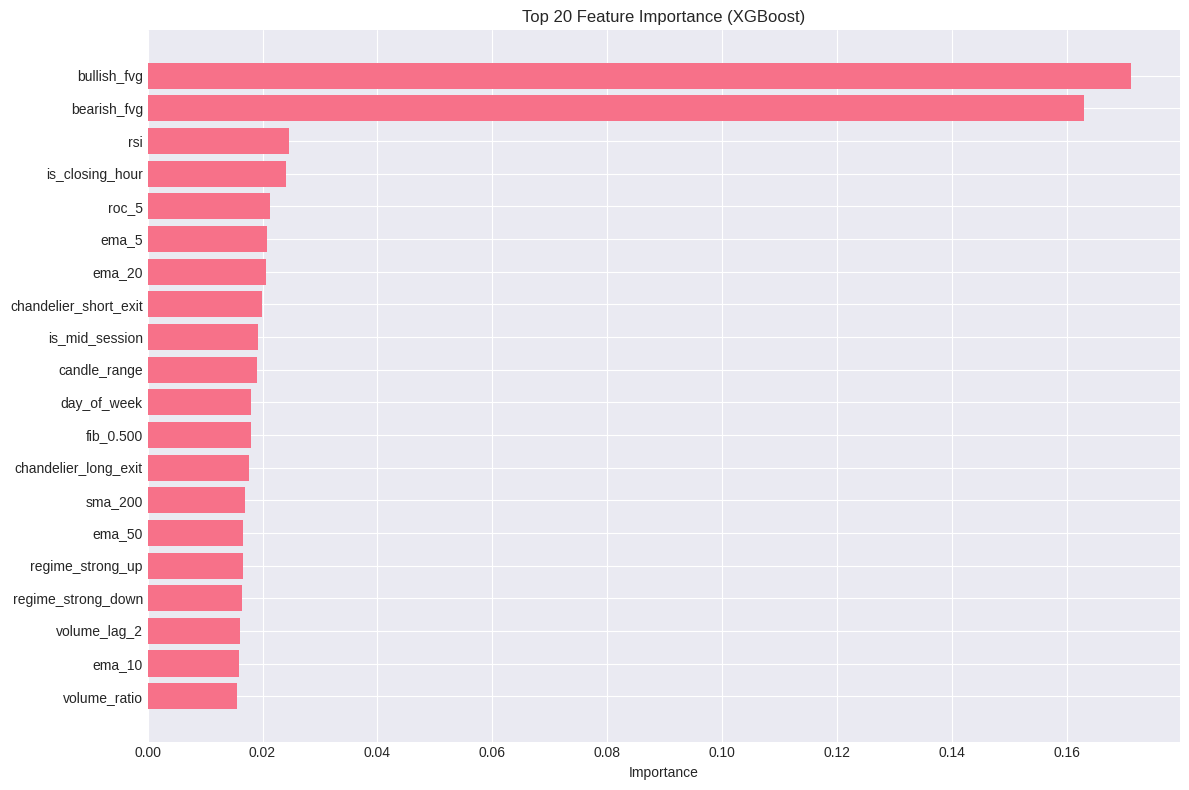


✓ Model diagnostics plot saved


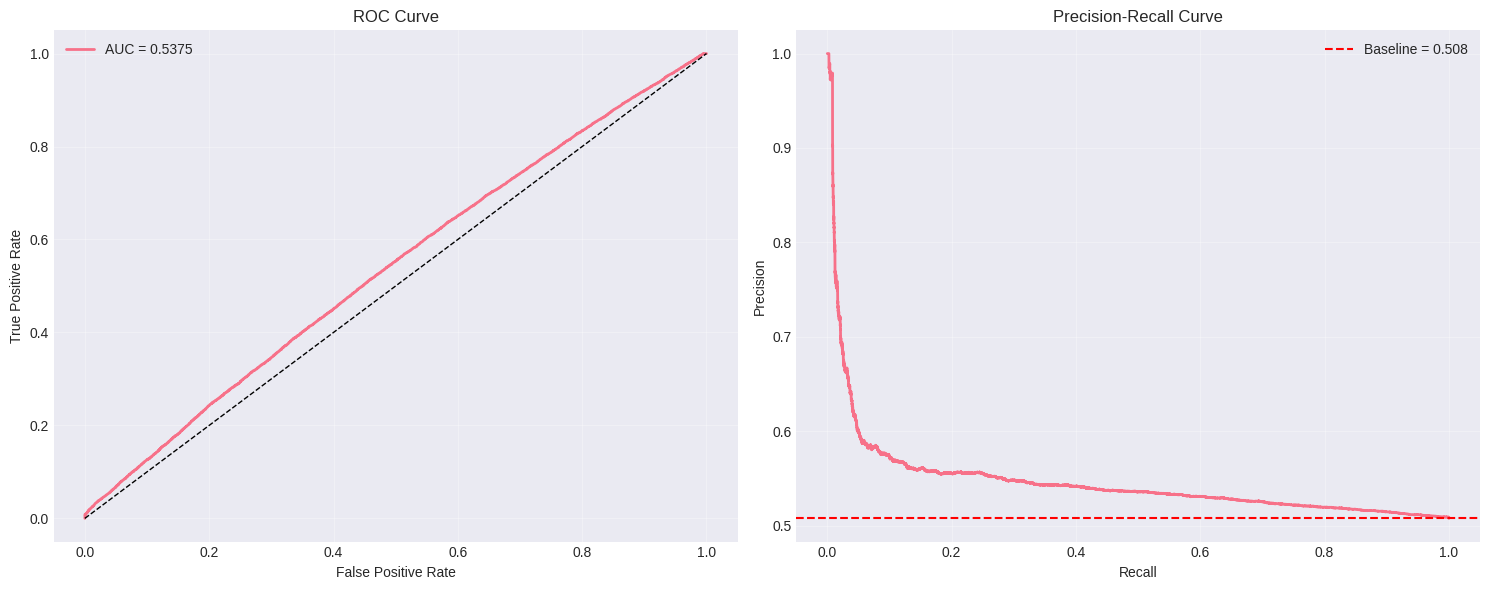


SAVING MODEL
✓ XGBoost model saved
✓ Scaler saved
✓ Best threshold saved: 0.3943
✓ Feature names saved

MODEL TRAINING COMPLETE!

Saved files:
  - xgboost_model.json
  - scaler.pkl
  - best_threshold.pkl
  - feature_names.pkl
  - feature_importance.png
  - model_diagnostics.png

Next step: Run backtesting script


In [ ]:
"""
XGBoost Model Training for FINNIFTY Trading System

This script trains an XGBoost classifier to predict future price direction
based on structure-based features (OTE, FVG, Market Regime)
"""

import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

#=============================================================================
# MODEL TRAINING
#=============================================================================

class XGBoostTrainer:
    """Train XGBoost model for trading signals"""

    def __init__(self):
        self.model = None
        self.scaler = None
        self.feature_names = None
        self.best_threshold = 0.5
        self.best_iteration = None

    def load_data(self):
        """Load preprocessed data"""
        print("\n" + "="*80)
        print("LOADING PREPROCESSED DATA")
        print("="*80)

        with open('/content/drive/MyDrive/finnifty_train_data.pkl', 'rb') as f:
            train_data = pickle.load(f)

        with open('/content/drive/MyDrive/finnifty_val_data.pkl', 'rb') as f:
            val_data = pickle.load(f)

        with open('/content/drive/MyDrive/finnifty_test_data.pkl', 'rb') as f:
            test_data = pickle.load(f)

        with open('/content/drive/MyDrive/feature_columns.pkl', 'rb') as f:
            self.feature_names = pickle.load(f)

        print(f"✓ Training samples: {len(train_data['X']):,}")
        print(f"✓ Validation samples: {len(val_data['X']):,}")
        print(f"✓ Test samples: {len(test_data['X']):,}")
        print(f"✓ Features: {len(self.feature_names)}")

        return train_data, val_data, test_data

    def scale_features(self, X_train, X_val, X_test):
        """
        Scale features using StandardScaler
        Important for tree-based models to handle different scales
        """
        print("\n" + "="*80)
        print("SCALING FEATURES")
        print("="*80)

        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        X_test_scaled = self.scaler.transform(X_test)

        print("✓ Features scaled using StandardScaler")

        return X_train_scaled, X_val_scaled, X_test_scaled

    def handle_class_imbalance(self, y_train):
        """
        Calculate scale_pos_weight for XGBoost
        This handles class imbalance without oversampling
        """
        n_negative = (y_train == 0).sum()
        n_positive = (y_train == 1).sum()
        scale_pos_weight = n_negative / n_positive

        print(f"\nClass distribution:")
        print(f"  Negative (0): {n_negative:,} ({n_negative/len(y_train)*100:.2f}%)")
        print(f"  Positive (1): {n_positive:,} ({n_positive/len(y_train)*100:.2f}%)")
        print(f"  Scale pos weight: {scale_pos_weight:.3f}")

        return scale_pos_weight

    def train_model(self, X_train, y_train, X_val, y_val, scale_pos_weight):
        """
        Train XGBoost model with optimized hyperparameters
        """
        print("\n" + "="*80)
        print("TRAINING XGBOOST MODEL")
        print("="*80)

        # XGBoost parameters (optimized for trading)
        params = {
            'objective': 'binary:logistic',
            'eval_metric': ['logloss', 'auc'],
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 1000,  # Increased for early stopping
            'min_child_weight': 3,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'gamma': 0.1,
            'reg_alpha': 0.1,  # L1 regularization
            'reg_lambda': 1.0,  # L2 regularization
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'n_jobs': -1,
            'tree_method': 'hist',  # Faster training
            'early_stopping_rounds': 50,  # Stop if no improvement for 50 rounds
        }

        # Create model
        self.model = xgb.XGBClassifier(**params)

        # Train with early stopping
        print("\nTraining in progress...")
        self.model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=50
        )

        print("\n✓ Model training complete!")

        # Get best iteration
        if hasattr(self.model, 'best_iteration'):
            print(f"✓ Best iteration: {self.model.best_iteration}")
            self.best_iteration = self.model.best_iteration
        else:
            print(f"✓ Training completed all {params['n_estimators']} iterations")
            self.best_iteration = params['n_estimators']

        return self.model

    def evaluate_model(self, X, y, dataset_name="Dataset"):
        """
        Evaluate model performance
        """
        print(f"\n{'='*80}")
        print(f"EVALUATING ON {dataset_name.upper()}")
        print(f"{'='*80}")

        # Predictions
        y_pred_proba = self.model.predict_proba(X)[:, 1]
        y_pred = (y_pred_proba > self.best_threshold).astype(int)

        # Classification metrics
        print("\nClassification Report:")
        print(classification_report(y, y_pred, target_names=['Down', 'Up']))

        # Confusion Matrix
        cm = confusion_matrix(y, y_pred)
        print("\nConfusion Matrix:")
        print(cm)

        # AUC Score
        auc = roc_auc_score(y, y_pred_proba)
        print(f"\nROC-AUC Score: {auc:.4f}")

        # Accuracy by prediction confidence
        high_conf_mask = (y_pred_proba > 0.7) | (y_pred_proba < 0.3)
        if high_conf_mask.sum() > 0:
            high_conf_acc = (y[high_conf_mask] == y_pred[high_conf_mask]).mean()
            print(f"High confidence accuracy (>0.7 or <0.3): {high_conf_acc:.4f} ({high_conf_mask.sum()} samples)")

        return {
            'predictions': y_pred,
            'probabilities': y_pred_proba,
            'auc': auc,
            'confusion_matrix': cm
        }

    def find_optimal_threshold(self, X_val, y_val):
        """
        Find optimal probability threshold using validation set
        Optimize for trading metrics (precision-recall trade-off)
        """
        print("\n" + "="*80)
        print("OPTIMIZING PROBABILITY THRESHOLD")
        print("="*80)

        y_pred_proba = self.model.predict_proba(X_val)[:, 1]

        # Calculate precision and recall for different thresholds
        precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

        # F1 scores for each threshold
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

        # Find threshold with best F1
        best_idx = np.argmax(f1_scores[:-1])  # Exclude last element
        self.best_threshold = thresholds[best_idx]

        print(f"\nOptimal threshold: {self.best_threshold:.4f}")
        print(f"Precision at optimal: {precisions[best_idx]:.4f}")
        print(f"Recall at optimal: {recalls[best_idx]:.4f}")
        print(f"F1 Score at optimal: {f1_scores[best_idx]:.4f}")

        # Also check default threshold performance
        y_pred_default = (y_pred_proba > 0.5).astype(int)
        from sklearn.metrics import f1_score, precision_score, recall_score

        print(f"\nDefault threshold (0.5) metrics:")
        print(f"Precision: {precision_score(y_val, y_pred_default):.4f}")
        print(f"Recall: {recall_score(y_val, y_pred_default):.4f}")
        print(f"F1 Score: {f1_score(y_val, y_pred_default):.4f}")

        return self.best_threshold

    def plot_feature_importance(self, top_n=20):
        """
        Plot feature importance
        """
        importance = self.model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'importance': importance
        }).sort_values('importance', ascending=False)

        print("\n" + "="*80)
        print(f"TOP {top_n} IMPORTANT FEATURES")
        print("="*80)
        print(feature_importance_df.head(top_n).to_string(index=False))

        # Plot
        plt.figure(figsize=(12, 8))
        top_features = feature_importance_df.head(top_n)
        plt.barh(range(len(top_features)), top_features['importance'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Importance')
        plt.title(f'Top {top_n} Feature Importance (XGBoost)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/feature_importance.png', dpi=150, bbox_inches='tight')
        print("\n✓ Feature importance plot saved")
        plt.show()

        return feature_importance_df

    def plot_model_diagnostics(self, val_results):
        """
        Plot ROC curve and Precision-Recall curve
        """
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # ROC Curve
        fpr, tpr, _ = roc_curve(val_results['y_true'], val_results['probabilities'])
        axes[0].plot(fpr, tpr, linewidth=2, label=f'AUC = {val_results["auc"]:.4f}')
        axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].set_title('ROC Curve')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(val_results['y_true'], val_results['probabilities'])
        axes[1].plot(recall, precision, linewidth=2)
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].set_title('Precision-Recall Curve')
        axes[1].axhline(y=val_results['y_true'].mean(), color='r', linestyle='--',
                       label=f'Baseline = {val_results["y_true"].mean():.3f}')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/model_diagnostics.png', dpi=150, bbox_inches='tight')
        print("\n✓ Model diagnostics plot saved")
        plt.show()

    def save_model(self):
        """
        Save trained model and scaler
        """
        print("\n" + "="*80)
        print("SAVING MODEL")
        print("="*80)

        # Save XGBoost model
        self.model.save_model('/content/drive/MyDrive/xgboost_model.json')
        print("✓ XGBoost model saved")

        # Save scaler
        with open('/content/drive/MyDrive/scaler.pkl', 'wb') as f:
            pickle.dump(self.scaler, f)
        print("✓ Scaler saved")

        # Save threshold
        with open('/content/drive/MyDrive/best_threshold.pkl', 'wb') as f:
            pickle.dump(self.best_threshold, f)
        print(f"✓ Best threshold saved: {self.best_threshold:.4f}")

        # Save feature names
        with open('/content/drive/MyDrive/feature_names.pkl', 'wb') as f:
            pickle.dump(self.feature_names, f)
        print("✓ Feature names saved")

#=============================================================================
# MAIN EXECUTION
#=============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("XGBOOST MODEL TRAINING")
    print("FINNIFTY Trading System")
    print("="*80)

    # Initialize trainer
    trainer = XGBoostTrainer()

    # Load data
    train_data, val_data, test_data = trainer.load_data()

    # Extract components
    X_train, y_train = train_data['X'], train_data['y']
    X_val, y_val = val_data['X'], val_data['y']
    X_test, y_test = test_data['X'], test_data['y']

    # Scale features
    X_train_scaled, X_val_scaled, X_test_scaled = trainer.scale_features(
        X_train, X_val, X_test
    )

    # Handle class imbalance
    scale_pos_weight = trainer.handle_class_imbalance(y_train)

    # Train model
    model = trainer.train_model(
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        scale_pos_weight
    )

    # Find optimal threshold on validation set
    best_threshold = trainer.find_optimal_threshold(X_val_scaled, y_val)

    # Evaluate on validation set
    val_results = trainer.evaluate_model(X_val_scaled, y_val, "VALIDATION SET")
    val_results['y_true'] = y_val

    # Evaluate on test set
    test_results = trainer.evaluate_model(X_test_scaled, y_test, "TEST SET")

    # Plot feature importance
    feature_importance_df = trainer.plot_feature_importance(top_n=20)

    # Plot diagnostics
    trainer.plot_model_diagnostics(val_results)

    # Save model
    trainer.save_model()

    print("\n" + "="*80)
    print("MODEL TRAINING COMPLETE!")
    print("="*80)
    print("\nSaved files:")
    print("  - xgboost_model.json")
    print("  - scaler.pkl")
    print("  - best_threshold.pkl")
    print("  - feature_names.pkl")
    print("  - feature_importance.png")
    print("  - model_diagnostics.png")
    print("\nNext step: Run backtesting script")


BACKTESTING ENGINE
FINNIFTY Trading System with XGBoost

LOADING TRAINED MODEL
✓ XGBoost model loaded
✓ Scaler loaded
✓ Threshold loaded: 0.3943
✓ Feature names loaded: 52 features

LOADING TEST DATA
✓ Test data loaded: 67,951 samples

Signal Generation:
  Raw ML signals: 67,703
  After OTE+FVG filter: 11
  After regime filter: 5
  Final signals: 5 (0.01%)

RUNNING BACKTEST

✓ Backtest complete!
  Total trades: 4
  Final capital: $99,991.43
  Total return: -0.01%

PERFORMANCE REPORT

📊 RISK-ADJUSTED RETURNS
--------------------------------------------------------------------------------
Sharpe Ratio:         13.5342
Sortino Ratio:         0.0000
Calmar Ratio:         -0.0023

💰 TRADE STATISTICS
--------------------------------------------------------------------------------
Total Trades:               4
Win Rate:               50.00%
Profit Factor:           1.55
Avg Win/Loss:            1.55
Expectancy:        $      0.86

📈 RETURNS
---------------------------------------------------

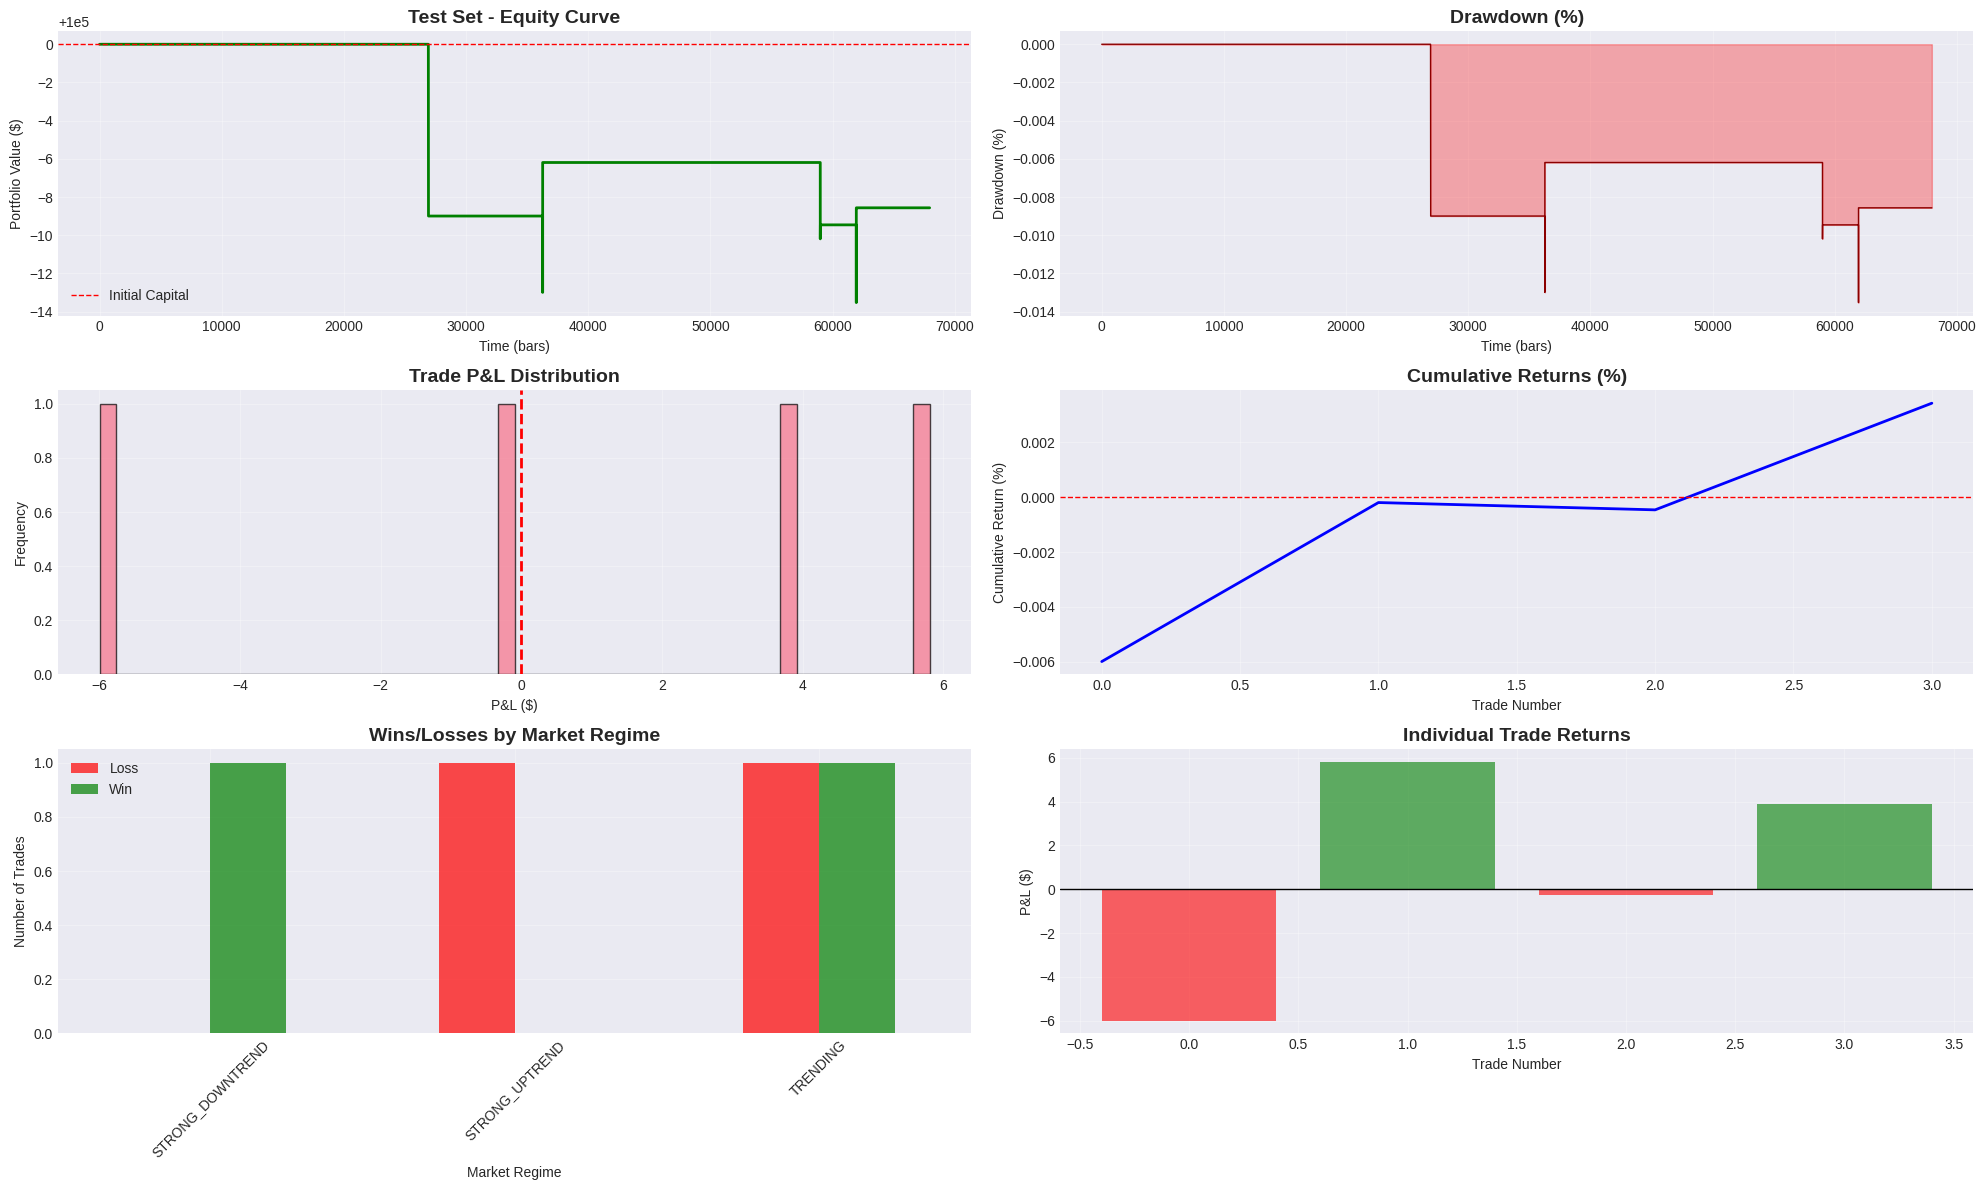


BACKTESTING COMPLETE!

Generated files:
  - trade_log.csv
  - backtest_metrics.csv
  - test_set_backtest_results.png


In [ ]:
"""
Backtesting Engine for FINNIFTY Trading System

Implements:
- Chandelier Exit trailing stop
- OTE entry filtering
- Comprehensive performance metrics
- Trade-by-trade analysis
"""

import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

#=============================================================================
# BACKTESTING ENGINE
#=============================================================================

class TradingBacktester:
    """
    Backtest trading strategy with realistic execution
    """

    def __init__(self, initial_capital=100000, position_size_pct=0.10,
                 commission_pct=0.0003, slippage_pct=0.0001):
        """
        Parameters:
        -----------
        initial_capital : float
            Starting capital
        position_size_pct : float
            Percentage of capital to risk per trade (10% = 0.10)
        commission_pct : float
            Commission as percentage of trade value (0.03% = 0.0003)
        slippage_pct : float
            Slippage as percentage (0.01% = 0.0001)
        """
        self.initial_capital = initial_capital
        self.position_size_pct = position_size_pct
        self.commission_pct = commission_pct
        self.slippage_pct = slippage_pct

        self.model = None
        self.scaler = None
        self.threshold = None
        self.feature_names = None

    def load_model(self):
        """Load trained model and preprocessing objects"""
        print("\n" + "="*80)
        print("LOADING TRAINED MODEL")
        print("="*80)

        # Load XGBoost model
        self.model = xgb.XGBClassifier()
        self.model.load_model('/content/drive/MyDrive/xgboost_model.json')
        print("✓ XGBoost model loaded")

        # Load scaler
        with open('/content/drive/MyDrive/scaler.pkl', 'rb') as f:
            self.scaler = pickle.load(f)
        print("✓ Scaler loaded")

        # Load threshold
        with open('/content/drive/MyDrive/best_threshold.pkl', 'rb') as f:
            self.threshold = pickle.load(f)
        print(f"✓ Threshold loaded: {self.threshold:.4f}")

        # Load feature names
        with open('/content/drive/MyDrive/feature_names.pkl', 'rb') as f:
            self.feature_names = pickle.load(f)
        print(f"✓ Feature names loaded: {len(self.feature_names)} features")

    def generate_signals(self, X, metadata_df):
        """
        Generate trading signals using trained model

        Returns:
        --------
        signals : array
            1 = Long, 0 = No trade
        probabilities : array
            Model prediction probabilities
        """
        # Scale features
        X_scaled = self.scaler.transform(X)

        # Get predictions
        probabilities = self.model.predict_proba(X_scaled)[:, 1]
        signals = (probabilities > self.threshold).astype(int)

        # Apply confluence filter: Only trade when in OTE zone AND FVG
        confluence_filter = metadata_df['in_ote_zone'] & metadata_df['in_fvg']

        # Also filter out ranging markets (only trade trends)
        regime_filter = metadata_df['market_regime'].isin(['TRENDING', 'STRONG_UPTREND', 'STRONG_DOWNTREND'])

        # Combined filter
        final_filter = confluence_filter & regime_filter

        # Apply filter to signals
        filtered_signals = signals.copy()
        filtered_signals[~final_filter] = 0

        print(f"\nSignal Generation:")
        print(f"  Raw ML signals: {signals.sum():,}")
        print(f"  After OTE+FVG filter: {(signals & confluence_filter).sum():,}")
        print(f"  After regime filter: {filtered_signals.sum():,}")
        print(f"  Final signals: {filtered_signals.sum():,} ({filtered_signals.sum()/len(filtered_signals)*100:.2f}%)")

        return filtered_signals, probabilities

    def backtest(self, X, metadata_df, signals, probabilities):
        """
        Run backtest with Chandelier exit strategy

        Returns:
        --------
        trades_df : DataFrame
            Detailed trade log
        equity_curve : array
            Portfolio value over time
        """
        print("\n" + "="*80)
        print("RUNNING BACKTEST")
        print("="*80)

        # Initialize
        capital = self.initial_capital
        equity_curve = [capital]
        trades = []

        in_position = False
        entry_price = 0
        entry_idx = 0
        entry_capital = 0
        shares = 0
        stop_loss = 0

        # Iterate through each bar
        for i in range(len(metadata_df)):
            current_price = metadata_df.iloc[i]['close']
            current_time = metadata_df.iloc[i]['datetime']

            # ENTRY LOGIC
            if not in_position and signals[i] == 1:
                # Calculate position size
                position_value = capital * self.position_size_pct

                # Account for slippage on entry
                entry_price = current_price * (1 + self.slippage_pct)

                # Calculate shares (for index, use points as "shares")
                shares = position_value / entry_price

                # Commission on entry
                commission = position_value * self.commission_pct

                # Update capital
                entry_capital = capital
                capital -= commission

                # Set stop loss using Chandelier exit
                stop_loss = metadata_df.iloc[i]['chandelier_long_exit']

                # Enter position
                in_position = True
                entry_idx = i

            # EXIT LOGIC
            elif in_position:
                # Update trailing stop (Chandelier)
                new_stop = metadata_df.iloc[i]['chandelier_long_exit']
                stop_loss = max(stop_loss, new_stop)  # Trail up only

                # Check exit conditions
                exit_triggered = False
                exit_reason = ""

                # 1. Stop loss hit
                if current_price <= stop_loss:
                    exit_triggered = True
                    exit_reason = "Stop Loss"
                    exit_price = stop_loss * (1 - self.slippage_pct)  # Slippage on exit

                # 2. Opposite signal
                elif signals[i] == 0 and probabilities[i] < (1 - self.threshold):
                    exit_triggered = True
                    exit_reason = "Opposite Signal"
                    exit_price = current_price * (1 - self.slippage_pct)

                # 3. End of data
                elif i == len(metadata_df) - 1:
                    exit_triggered = True
                    exit_reason = "End of Data"
                    exit_price = current_price * (1 - self.slippage_pct)

                # Execute exit
                if exit_triggered:
                    # Calculate P&L
                    position_value = shares * exit_price
                    commission = position_value * self.commission_pct
                    pnl = position_value - (shares * entry_price) - commission
                    pnl_pct = (pnl / entry_capital) * 100

                    # Update capital
                    capital += pnl

                    # Record trade
                    trade = {
                        'entry_time': metadata_df.iloc[entry_idx]['datetime'],
                        'exit_time': current_time,
                        'entry_price': entry_price,
                        'exit_price': exit_price,
                        'shares': shares,
                        'pnl': pnl,
                        'pnl_pct': pnl_pct,
                        'return': (exit_price / entry_price) - 1,
                        'exit_reason': exit_reason,
                        'holding_period': i - entry_idx,
                        'entry_capital': entry_capital,
                        'exit_capital': capital,
                        'in_ote_zone': metadata_df.iloc[entry_idx]['in_ote_zone'],
                        'in_fvg': metadata_df.iloc[entry_idx]['in_fvg'],
                        'market_regime': metadata_df.iloc[entry_idx]['market_regime'],
                        'probability': probabilities[entry_idx],
                    }
                    trades.append(trade)

                    # Reset position
                    in_position = False
                    entry_price = 0
                    entry_idx = 0
                    shares = 0
                    stop_loss = 0

            # Update equity curve
            if in_position:
                # Mark-to-market
                current_position_value = shares * current_price
                current_equity = capital + current_position_value - (shares * entry_price)
            else:
                current_equity = capital

            equity_curve.append(current_equity)

        # Create trades DataFrame
        trades_df = pd.DataFrame(trades)

        if len(trades_df) > 0:
            trades_df['profitable'] = (trades_df['pnl'] > 0).astype(int)

        print(f"\n✓ Backtest complete!")
        print(f"  Total trades: {len(trades_df)}")
        print(f"  Final capital: ${capital:,.2f}")
        print(f"  Total return: {((capital - self.initial_capital) / self.initial_capital * 100):.2f}%")

        return trades_df, np.array(equity_curve)

#=============================================================================
# PERFORMANCE METRICS
#=============================================================================

class PerformanceEvaluator:
    """Calculate comprehensive trading performance metrics"""

    @staticmethod
    def calculate_sharpe_ratio(returns, risk_free_rate=0.0):
        """
        Sharpe Ratio = (Mean Return - Risk Free Rate) / Std Dev of Returns
        Annualized assuming 252 trading days
        """
        if len(returns) == 0 or returns.std() == 0:
            return 0.0

        mean_return = returns.mean()
        std_return = returns.std()
        sharpe = (mean_return - risk_free_rate) / std_return * np.sqrt(252)

        return sharpe

    @staticmethod
    def calculate_sortino_ratio(returns, risk_free_rate=0.0):
        """
        Sortino Ratio = (Mean Return - Risk Free Rate) / Downside Std Dev
        Only considers downside volatility
        """
        if len(returns) == 0:
            return 0.0

        downside_returns = returns[returns < 0]
        if len(downside_returns) == 0 or downside_returns.std() == 0:
            return 0.0

        mean_return = returns.mean()
        downside_std = downside_returns.std()
        sortino = (mean_return - risk_free_rate) / downside_std * np.sqrt(252)

        return sortino

    @staticmethod
    def calculate_calmar_ratio(equity_curve, returns):
        """
        Calmar Ratio = Annualized Return / Maximum Drawdown
        """
        if len(equity_curve) < 2:
            return 0.0

        # Annualized return
        total_return = (equity_curve[-1] / equity_curve[0]) - 1
        years = len(equity_curve) / 252  # Assuming daily data
        if years == 0:
            return 0.0
        annual_return = (1 + total_return) ** (1 / years) - 1

        # Maximum drawdown
        max_dd = PerformanceEvaluator.calculate_max_drawdown(equity_curve)

        if max_dd == 0:
            return 0.0

        calmar = annual_return / abs(max_dd)

        return calmar

    @staticmethod
    def calculate_max_drawdown(equity_curve):
        """
        Maximum Drawdown = (Trough - Peak) / Peak
        """
        if len(equity_curve) < 2:
            return 0.0

        equity = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity)
        drawdown = (equity - running_max) / running_max
        max_dd = drawdown.min()

        return max_dd

    @staticmethod
    def calculate_drawdown_stats(equity_curve):
        """
        Calculate drawdown statistics
        """
        if len(equity_curve) < 2:
            return {
                'max_drawdown': 0,
                'avg_drawdown': 0,
                'max_drawdown_duration': 0,
                'avg_drawdown_duration': 0,
                'recovery_time': 0
            }

        equity = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity)
        drawdown = (equity - running_max) / running_max

        # Find drawdown periods
        is_drawdown = drawdown < 0
        drawdown_periods = []
        start_idx = None

        for i in range(len(is_drawdown)):
            if is_drawdown[i] and start_idx is None:
                start_idx = i
            elif not is_drawdown[i] and start_idx is not None:
                drawdown_periods.append({
                    'start': start_idx,
                    'end': i,
                    'duration': i - start_idx,
                    'magnitude': drawdown[start_idx:i].min()
                })
                start_idx = None

        # If still in drawdown at end
        if start_idx is not None:
            drawdown_periods.append({
                'start': start_idx,
                'end': len(equity) - 1,
                'duration': len(equity) - 1 - start_idx,
                'magnitude': drawdown[start_idx:].min()
            })

        if len(drawdown_periods) == 0:
            return {
                'max_drawdown': 0,
                'avg_drawdown': 0,
                'max_drawdown_duration': 0,
                'avg_drawdown_duration': 0,
                'recovery_time': 0
            }

        drawdown_mags = [dd['magnitude'] for dd in drawdown_periods]
        drawdown_durs = [dd['duration'] for dd in drawdown_periods]

        # Find recovery time for max drawdown
        max_dd_period = drawdown_periods[np.argmin(drawdown_mags)]
        recovery_time = max_dd_period['duration']

        return {
            'max_drawdown': min(drawdown_mags),
            'avg_drawdown': np.mean(drawdown_mags),
            'max_drawdown_duration': max(drawdown_durs),
            'avg_drawdown_duration': np.mean(drawdown_durs),
            'recovery_time': recovery_time,
            'num_drawdown_periods': len(drawdown_periods)
        }

    @staticmethod
    def calculate_trade_metrics(trades_df):
        """
        Calculate trade-specific metrics
        """
        if len(trades_df) == 0:
            return {}

        # Win rate
        win_rate = (trades_df['profitable'].sum() / len(trades_df)) * 100

        # Profit factor
        gross_profit = trades_df[trades_df['pnl'] > 0]['pnl'].sum()
        gross_loss = abs(trades_df[trades_df['pnl'] < 0]['pnl'].sum())
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

        # Average win/loss
        avg_win = trades_df[trades_df['pnl'] > 0]['pnl'].mean() if (trades_df['pnl'] > 0).any() else 0
        avg_loss = trades_df[trades_df['pnl'] < 0]['pnl'].mean() if (trades_df['pnl'] < 0).any() else 0
        avg_win_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf

        # Expectancy
        win_pct = trades_df['profitable'].mean()
        loss_pct = 1 - win_pct
        expectancy = (win_pct * avg_win) - (loss_pct * abs(avg_loss))

        # Holding period
        avg_holding_period = trades_df['holding_period'].mean()

        # Consecutive wins/losses
        consecutive_wins = 0
        consecutive_losses = 0
        max_consecutive_wins = 0
        max_consecutive_losses = 0

        for profitable in trades_df['profitable']:
            if profitable:
                consecutive_wins += 1
                consecutive_losses = 0
                max_consecutive_wins = max(max_consecutive_wins, consecutive_wins)
            else:
                consecutive_losses += 1
                consecutive_wins = 0
                max_consecutive_losses = max(max_consecutive_losses, consecutive_losses)

        return {
            'total_trades': len(trades_df),
            'win_rate': win_rate,
            'profit_factor': profit_factor,
            'avg_win': avg_win,
            'avg_loss': avg_loss,
            'avg_win_loss_ratio': avg_win_loss_ratio,
            'expectancy': expectancy,
            'avg_holding_period': avg_holding_period,
            'max_consecutive_wins': max_consecutive_wins,
            'max_consecutive_losses': max_consecutive_losses,
            'gross_profit': gross_profit,
            'gross_loss': gross_loss
        }

    @staticmethod
    def calculate_ote_metrics(trades_df):
        """
        Calculate OTE-specific metrics
        """
        if len(trades_df) == 0:
            return {}

        # OTE entries
        ote_entries = trades_df[trades_df['in_ote_zone'] == True]
        non_ote_entries = trades_df[trades_df['in_ote_zone'] == False]

        ote_win_rate = (ote_entries['profitable'].mean() * 100) if len(ote_entries) > 0 else 0
        ote_avg_return = ote_entries['return'].mean() if len(ote_entries) > 0 else 0

        non_ote_win_rate = (non_ote_entries['profitable'].mean() * 100) if len(non_ote_entries) > 0 else 0

        ote_advantage = ote_win_rate - non_ote_win_rate

        return {
            'ote_entries': len(ote_entries),
            'ote_win_rate': ote_win_rate,
            'ote_avg_return': ote_avg_return,
            'non_ote_entries': len(non_ote_entries),
            'non_ote_win_rate': non_ote_win_rate,
            'ote_advantage': ote_advantage
        }

    @staticmethod
    def generate_performance_report(trades_df, equity_curve, initial_capital):
        """
        Generate comprehensive performance report
        """
        print("\n" + "="*80)
        print("PERFORMANCE REPORT")
        print("="*80)

        if len(trades_df) == 0:
            print("\nNo trades executed!")
            return {}

        # Calculate returns
        returns = trades_df['return'].values

        # Risk-adjusted metrics
        sharpe = PerformanceEvaluator.calculate_sharpe_ratio(returns)
        sortino = PerformanceEvaluator.calculate_sortino_ratio(returns)
        calmar = PerformanceEvaluator.calculate_calmar_ratio(equity_curve, returns)

        # Drawdown stats
        dd_stats = PerformanceEvaluator.calculate_drawdown_stats(equity_curve)

        # Trade metrics
        trade_metrics = PerformanceEvaluator.calculate_trade_metrics(trades_df)

        # OTE metrics
        ote_metrics = PerformanceEvaluator.calculate_ote_metrics(trades_df)

        # Overall performance
        total_return = ((equity_curve[-1] - initial_capital) / initial_capital) * 100

        # Print report
        print("\n📊 RISK-ADJUSTED RETURNS")
        print("-" * 80)
        print(f"Sharpe Ratio:      {sharpe:>10.4f}")
        print(f"Sortino Ratio:     {sortino:>10.4f}")
        print(f"Calmar Ratio:      {calmar:>10.4f}")

        print("\n💰 TRADE STATISTICS")
        print("-" * 80)
        print(f"Total Trades:      {trade_metrics['total_trades']:>10,}")
        print(f"Win Rate:          {trade_metrics['win_rate']:>10.2f}%")
        print(f"Profit Factor:     {trade_metrics['profit_factor']:>10.2f}")
        print(f"Avg Win/Loss:      {trade_metrics['avg_win_loss_ratio']:>10.2f}")
        print(f"Expectancy:        ${trade_metrics['expectancy']:>10,.2f}")

        print("\n📈 RETURNS")
        print("-" * 80)
        print(f"Total Return:      {total_return:>10.2f}%")
        print(f"Gross Profit:      ${trade_metrics['gross_profit']:>10,.2f}")
        print(f"Gross Loss:        ${trade_metrics['gross_loss']:>10,.2f}")
        print(f"Average Win:       ${trade_metrics['avg_win']:>10,.2f}")
        print(f"Average Loss:      ${trade_metrics['avg_loss']:>10,.2f}")

        print("\n📉 DRAWDOWN ANALYSIS")
        print("-" * 80)
        print(f"Max Drawdown:      {dd_stats['max_drawdown']*100:>10.2f}%")
        print(f"Avg Drawdown:      {dd_stats['avg_drawdown']*100:>10.2f}%")
        print(f"Max DD Duration:   {dd_stats['max_drawdown_duration']:>10,} bars")
        print(f"Avg DD Duration:   {dd_stats['avg_drawdown_duration']:>10.1f} bars")
        print(f"Recovery Time:     {dd_stats['recovery_time']:>10,} bars")

        print("\n🎯 OTE ENTRY QUALITY")
        print("-" * 80)
        print(f"OTE Entries:       {ote_metrics['ote_entries']:>10,}")
        print(f"OTE Win Rate:      {ote_metrics['ote_win_rate']:>10.2f}%")
        print(f"OTE Avg Return:    {ote_metrics['ote_avg_return']*100:>10.2f}%")
        print(f"Non-OTE Entries:   {ote_metrics['non_ote_entries']:>10,}")
        print(f"Non-OTE Win Rate:  {ote_metrics['non_ote_win_rate']:>10.2f}%")
        print(f"OTE Advantage:     {ote_metrics['ote_advantage']:>10.2f}%")

        print("\n⏱️  TRADE QUALITY")
        print("-" * 80)
        print(f"Avg Hold Period:   {trade_metrics['avg_holding_period']:>10.1f} bars")
        print(f"Max Consec Wins:   {trade_metrics['max_consecutive_wins']:>10,}")
        print(f"Max Consec Losses: {trade_metrics['max_consecutive_losses']:>10,}")

        # Combine all metrics
        all_metrics = {
            'sharpe_ratio': sharpe,
            'sortino_ratio': sortino,
            'calmar_ratio': calmar,
            'total_return_pct': total_return,
            **trade_metrics,
            **dd_stats,
            **ote_metrics
        }

        return all_metrics

#=============================================================================
# VISUALIZATION
#=============================================================================

def plot_backtest_results(equity_curve, trades_df, metadata_df, dataset_name="Test"):
    """
    Plot comprehensive backtest visualizations
    """
    fig = plt.figure(figsize=(20, 12))

    # 1. Equity Curve
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(equity_curve, linewidth=2, color='green')
    ax1.set_title(f'{dataset_name} - Equity Curve', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Time (bars)')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=equity_curve[0], color='red', linestyle='--', linewidth=1, label='Initial Capital')
    ax1.legend()

    # 2. Drawdown
    ax2 = plt.subplot(3, 2, 2)
    equity = np.array(equity_curve)
    running_max = np.maximum.accumulate(equity)
    drawdown = (equity - running_max) / running_max * 100
    ax2.fill_between(range(len(drawdown)), drawdown, 0, color='red', alpha=0.3)
    ax2.plot(drawdown, color='darkred', linewidth=1)
    ax2.set_title('Drawdown (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time (bars)')
    ax2.set_ylabel('Drawdown (%)')
    ax2.grid(True, alpha=0.3)

    # 3. Trade P&L Distribution
    if len(trades_df) > 0:
        ax3 = plt.subplot(3, 2, 3)
        ax3.hist(trades_df['pnl'], bins=50, edgecolor='black', alpha=0.7)
        ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
        ax3.set_title('Trade P&L Distribution', fontsize=14, fontweight='bold')
        ax3.set_xlabel('P&L ($)')
        ax3.set_ylabel('Frequency')
        ax3.grid(True, alpha=0.3)

        # 4. Cumulative Returns
        ax4 = plt.subplot(3, 2, 4)
        cumulative_returns = (trades_df['pnl'].cumsum() / equity_curve[0]) * 100
        ax4.plot(cumulative_returns.values, linewidth=2, color='blue')
        ax4.set_title('Cumulative Returns (%)', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Trade Number')
        ax4.set_ylabel('Cumulative Return (%)')
        ax4.grid(True, alpha=0.3)
        ax4.axhline(y=0, color='red', linestyle='--', linewidth=1)

        # 5. Win/Loss by Market Regime
        ax5 = plt.subplot(3, 2, 5)
        regime_performance = trades_df.groupby(['market_regime', 'profitable']).size().unstack(fill_value=0)
        regime_performance.plot(kind='bar', ax=ax5, color=['red', 'green'], alpha=0.7)
        ax5.set_title('Wins/Losses by Market Regime', fontsize=14, fontweight='bold')
        ax5.set_xlabel('Market Regime')
        ax5.set_ylabel('Number of Trades')
        ax5.legend(['Loss', 'Win'])
        ax5.grid(True, alpha=0.3)
        plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45)

        # 6. Returns over Time
        ax6 = plt.subplot(3, 2, 6)
        trades_df['trade_num'] = range(len(trades_df))
        colors = ['green' if x > 0 else 'red' for x in trades_df['pnl']]
        ax6.bar(trades_df['trade_num'], trades_df['pnl'], color=colors, alpha=0.6)
        ax6.set_title('Individual Trade Returns', fontsize=14, fontweight='bold')
        ax6.set_xlabel('Trade Number')
        ax6.set_ylabel('P&L ($)')
        ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{dataset_name.lower()}_backtest_results.png',
                dpi=150, bbox_inches='tight')
    print(f"\n✓ Backtest visualization saved: {dataset_name.lower()}_backtest_results.png")
    plt.show()

#=============================================================================
# MAIN EXECUTION
#=============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("BACKTESTING ENGINE")
    print("FINNIFTY Trading System with XGBoost")
    print("="*80)

    # Initialize backtester
    backtester = TradingBacktester(
        initial_capital=100000,
        position_size_pct=0.10,  # 10% of capital per trade
        commission_pct=0.0003,    # 0.03%
        slippage_pct=0.0001       # 0.01%
    )

    # Load trained model
    backtester.load_model()

    # Load test data
    print("\n" + "="*80)
    print("LOADING TEST DATA")
    print("="*80)

    with open('/content/drive/MyDrive/finnifty_test_data.pkl', 'rb') as f:
        test_data = pickle.load(f)

    X_test = test_data['X']
    y_test = test_data['y']
    test_metadata = test_data['metadata']

    print(f"✓ Test data loaded: {len(X_test):,} samples")

    # Generate signals
    signals, probabilities = backtester.generate_signals(X_test, test_metadata)

    # Run backtest
    trades_df, equity_curve = backtester.backtest(X_test, test_metadata, signals, probabilities)

    # Calculate performance metrics
    evaluator = PerformanceEvaluator()
    metrics = evaluator.generate_performance_report(
        trades_df, equity_curve, backtester.initial_capital
    )

    # Save results
    if len(trades_df) > 0:
        trades_df.to_csv('/content/drive/MyDrive/trade_log.csv', index=False)
        print("\n✓ Trade log saved: trade_log.csv")

    # Save metrics
    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv('/content/drive/MyDrive/backtest_metrics.csv', index=False)
    print("✓ Metrics saved: backtest_metrics.csv")

    # Plot results
    plot_backtest_results(equity_curve, trades_df, test_metadata, "Test Set")

    print("\n" + "="*80)
    print("BACKTESTING COMPLETE!")
    print("="*80)
    print("\nGenerated files:")
    print("  - trade_log.csv")
    print("  - backtest_metrics.csv")
    print("  - test_set_backtest_results.png")


XGBOOST HYPERPARAMETER TUNING
FINNIFTY Trading System
Bayesian Optimization with Optuna - 50 Trials

LOADING DATA FOR HYPERPARAMETER TUNING
✓ Training samples: 253,327
✓ Validation samples: 44,849


[I 2026-01-30 11:25:08,622] A new study created in memory with name: xgboost_finnifty_tuning



STARTING HYPERPARAMETER TUNING - 50 TRIALS

Class distribution:
  Negative: 126,269 (49.84%)
  Positive: 127,058 (50.16%)
  Scale pos weight: 0.994

Optimizing for F1 Score...
This may take 30-60 minutes depending on your hardware.



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-01-30 11:26:34,385] Trial 0 finished with value: 0.674390695607082 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 1500, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'colsample_bylevel': 0.5290418060840998, 'gamma': 0.8661761457749352, 'reg_alpha': 6.011150117432088, 'reg_lambda': 7.080725777960454, 'max_delta_step': 0}. Best is trial 0 with value: 0.674390695607082.
[I 2026-01-30 11:27:41,775] Trial 1 finished with value: 0.6742914709847553 and parameters: {'max_depth': 10, 'learning_rate': 0.16967533607196555, 'n_estimators': 500, 'min_child_weight': 2, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.6521211214797689, 'colsample_bylevel': 0.762378215816119, 'gamma': 0.43194501864211576, 'reg_alpha': 2.9122914019804194, 'reg_lambda': 6.118528947223795, 'max_delta_step': 0}. Best is trial 0 with value: 0.674390695607082.
[I 2026-01-30 11:28:36,475] Trial 2 finished with value: 0.6745

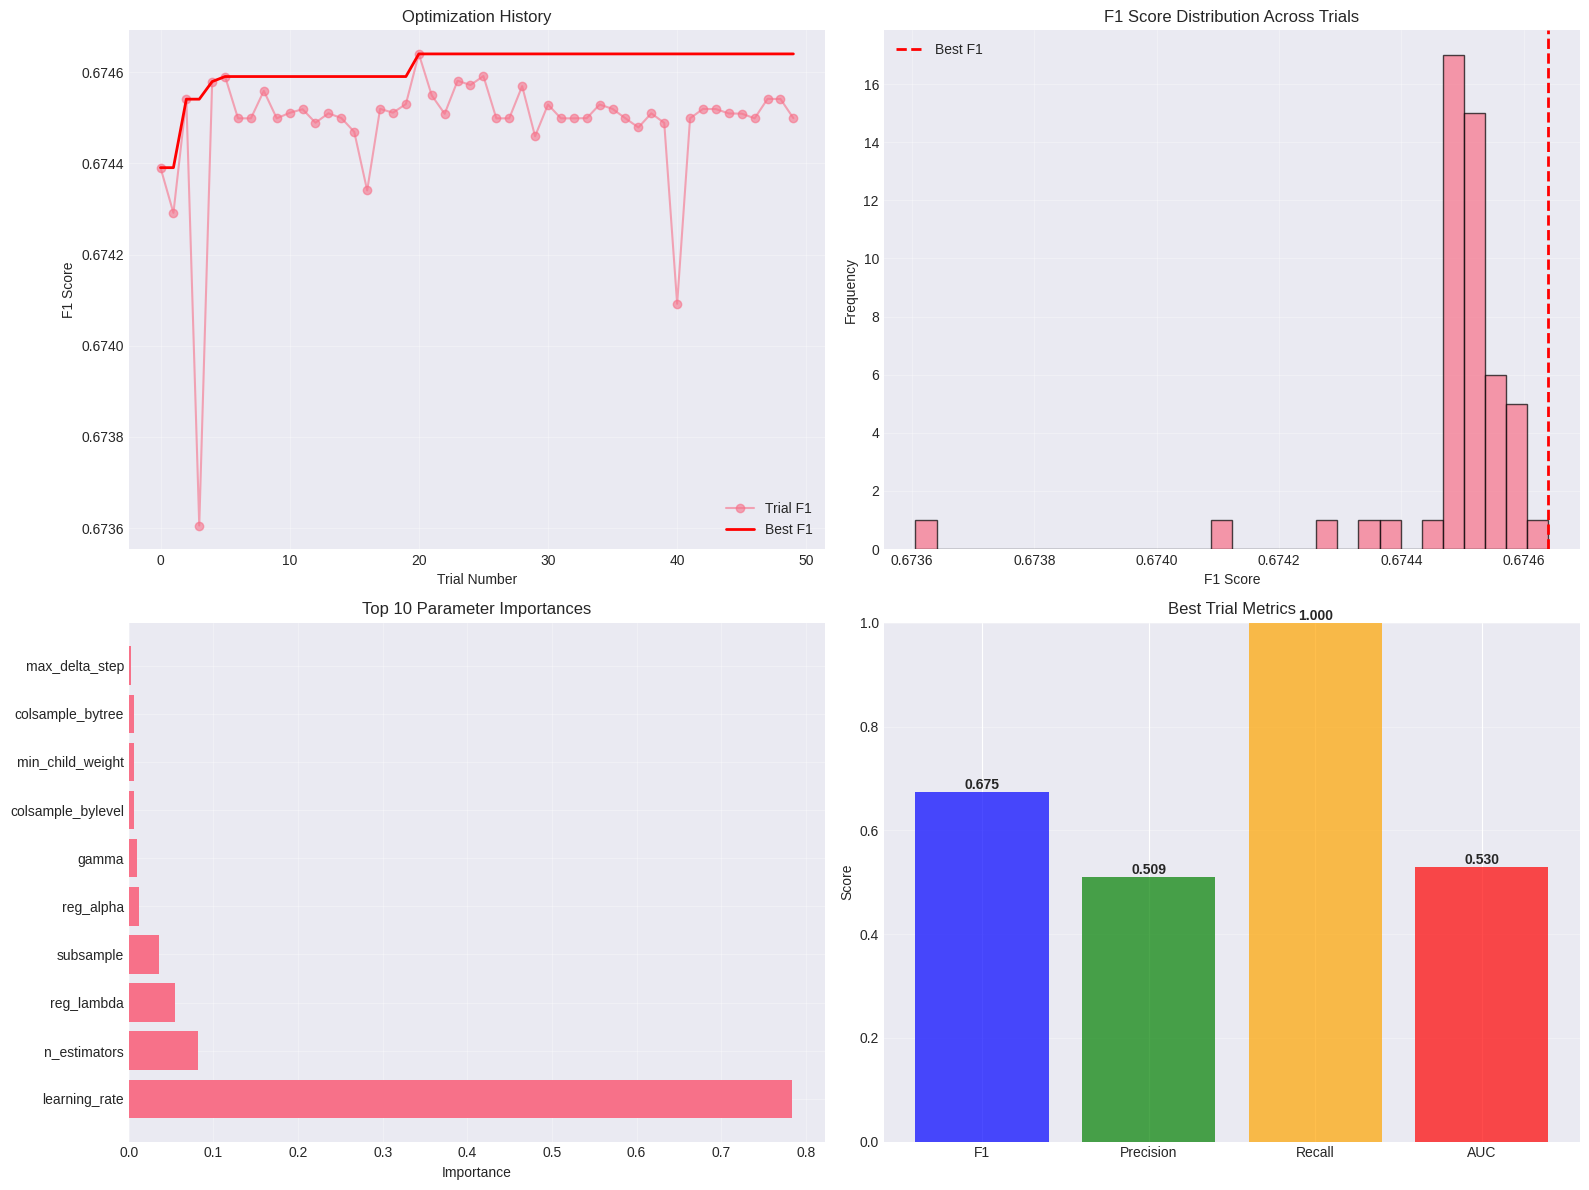

Note: Could not create parallel coordinate plot: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


SAVING RESULTS
✓ Best hyperparameters saved
✓ Tuned model saved
✓ Scaler saved
✓ Optimal threshold saved: 0.3794
✓ Trial history saved
✓ Summary saved

HYPERPARAMETER TUNING COMPLETE!

Generated files:
  - best_hyperparameters.pkl
  - tuned_xgboost_model.json
  - tuned_scaler.pkl
  - tuned_best_threshold.pkl
  - tuning_trials_history.csv
  - tuning_summary.csv
  - hyperparameter_tuning_results.png
  - parallel_coordinate.png (if available)

Next step: Use the tuned model in the main trading system

To use the tuned model, replace the model loading in the main script with:
  model.load_model('/content/drive/MyDrive/tuned_xgboost_model.json')


In [ ]:
# Install Optuna for hyperparameter tuning if not already installed
!pip install optuna

import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#=============================================================================
# HYPERPARAMETER TUNING WITH OPTUNA
#=============================================================================

class XGBoostHyperparameterTuner:
    """
    Tune XGBoost hyperparameters using Optuna
    """

    def __init__(self, n_trials=50):
        self.n_trials = n_trials
        self.study = None
        self.best_params = None
        self.best_model = None
        self.scaler = StandardScaler()

    def load_data(self):
        """Load preprocessed training and validation data"""
        print("\n" + "="*80)
        print("LOADING DATA FOR HYPERPARAMETER TUNING")
        print("="*80)

        with open('/content/drive/MyDrive/finnifty_train_data.pkl', 'rb') as f:
            train_data = pickle.load(f)

        with open('/content/drive/MyDrive/finnifty_val_data.pkl', 'rb') as f:
            val_data = pickle.load(f)

        print(f"✓ Training samples: {len(train_data['X']):,}")
        print(f"✓ Validation samples: {len(val_data['X']):,}")

        return train_data, val_data

    def scale_data(self, X_train, X_val):
        """Scale features"""
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        return X_train_scaled, X_val_scaled

    def objective(self, trial, X_train, y_train, X_val, y_val, scale_pos_weight):
        """
        Objective function for Optuna
        Returns: F1 score on validation set
        """

        # Define hyperparameter search space
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1,
            'tree_method': 'hist',

            # Hyperparameters to tune
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 100, 2000, step=100),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
            'scale_pos_weight': scale_pos_weight,
            'max_delta_step': trial.suggest_int('max_delta_step', 0, 5),
        }

        # Train model
        model = xgb.XGBClassifier(**params)

        # Use early stopping with a subset for faster trials
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Predict on validation set
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # Find optimal threshold for this model
        from sklearn.metrics import precision_recall_curve
        precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        best_threshold_idx = np.argmax(f1_scores[:-1])
        optimal_threshold = thresholds[best_threshold_idx]

        # Make predictions with optimal threshold
        y_pred = (y_pred_proba > optimal_threshold).astype(int)

        # Calculate F1 score
        f1 = f1_score(y_val, y_pred)

        # Also log other metrics for analysis
        precision = precision_score(y_val, y_pred)
        recall = recall_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_pred_proba)

        trial.set_user_attr('precision', precision)
        trial.set_user_attr('recall', recall)
        trial.set_user_attr('auc', auc)
        trial.set_user_attr('optimal_threshold', optimal_threshold)

        return f1

    def tune(self, X_train, y_train, X_val, y_val):
        """
        Run hyperparameter tuning
        """
        print("\n" + "="*80)
        print(f"STARTING HYPERPARAMETER TUNING - {self.n_trials} TRIALS")
        print("="*80)

        # Calculate scale_pos_weight
        n_negative = (y_train == 0).sum()
        n_positive = (y_train == 1).sum()
        scale_pos_weight = n_negative / n_positive

        print(f"\nClass distribution:")
        print(f"  Negative: {n_negative:,} ({n_negative/len(y_train)*100:.2f}%)")
        print(f"  Positive: {n_positive:,} ({n_positive/len(y_train)*100:.2f}%)")
        print(f"  Scale pos weight: {scale_pos_weight:.3f}")

        # Create Optuna study
        print(f"\nOptimizing for F1 Score...")
        print("This may take 30-60 minutes depending on your hardware.\n")

        self.study = optuna.create_study(
            direction='maximize',
            study_name='xgboost_finnifty_tuning',
            sampler=optuna.samplers.TPESampler(seed=42)
        )

        # Run optimization
        self.study.optimize(
            lambda trial: self.objective(trial, X_train, y_train, X_val, y_val, scale_pos_weight),
            n_trials=self.n_trials,
            show_progress_bar=True
        )

        # Get best parameters
        self.best_params = self.study.best_params
        self.best_params['scale_pos_weight'] = scale_pos_weight
        self.best_params['objective'] = 'binary:logistic'
        self.best_params['eval_metric'] = 'logloss'
        self.best_params['random_state'] = 42
        self.best_params['n_jobs'] = -1
        self.best_params['tree_method'] = 'hist'

        print("\n" + "="*80)
        print("HYPERPARAMETER TUNING COMPLETE!")
        print("="*80)

        print(f"\nBest F1 Score: {self.study.best_value:.4f}")
        print(f"Best Trial: #{self.study.best_trial.number}")

        print("\nBest Hyperparameters:")
        print("-" * 80)
        for param, value in self.study.best_params.items():
            print(f"  {param:<20}: {value}")

        # Print metrics from best trial
        best_trial = self.study.best_trial
        print("\nMetrics from Best Trial:")
        print("-" * 80)
        print(f"  F1 Score:          {best_trial.value:.4f}")
        print(f"  Precision:         {best_trial.user_attrs['precision']:.4f}")
        print(f"  Recall:            {best_trial.user_attrs['recall']:.4f}")
        print(f"  AUC:               {best_trial.user_attrs['auc']:.4f}")
        print(f"  Optimal Threshold: {best_trial.user_attrs['optimal_threshold']:.4f}")

        return self.best_params

    def train_best_model(self, X_train, y_train, X_val, y_val):
        """
        Train final model with best hyperparameters
        """
        print("\n" + "="*80)
        print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
        print("="*80)

        # Train model
        self.best_model = xgb.XGBClassifier(**self.best_params)

        self.best_model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=50
        )

        print("\n✓ Final model training complete!")

        return self.best_model

    def evaluate_best_model(self, X_val, y_val):
        """
        Evaluate best model on validation set
        """
        print("\n" + "="*80)
        print("EVALUATING BEST MODEL")
        print("="*80)

        # Get optimal threshold from best trial
        optimal_threshold = self.study.best_trial.user_attrs['optimal_threshold']

        # Predictions
        y_pred_proba = self.best_model.predict_proba(X_val)[:, 1]
        y_pred = (y_pred_proba > optimal_threshold).astype(int)

        # Metrics
        from sklearn.metrics import classification_report, confusion_matrix

        print("\nClassification Report:")
        print(classification_report(y_val, y_pred, target_names=['Down', 'Up']))

        print("\nConfusion Matrix:")
        cm = confusion_matrix(y_val, y_pred)
        print(cm)

        f1 = f1_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred)
        recall = recall_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_pred_proba)

        print(f"\nMetrics:")
        print(f"  F1 Score:    {f1:.4f}")
        print(f"  Precision:   {precision:.4f}")
        print(f"  Recall:      {recall:.4f}")
        print(f"  AUC:         {auc:.4f}")

        return {
            'f1': f1,
            'precision': precision,
            'recall': recall,
            'auc': auc,
            'optimal_threshold': optimal_threshold
        }

    def plot_optimization_results(self):
        """
        Plot optimization history and parameter importances
        """
        print("\n" + "="*80)
        print("GENERATING OPTIMIZATION PLOTS")
        print("="*80)

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # 1. Optimization History
        ax1 = axes[0, 0]
        trials = self.study.trials
        trial_numbers = [t.number for t in trials]
        trial_values = [t.value for t in trials]
        best_values = [max(trial_values[:i+1]) for i in range(len(trial_values))]

        ax1.plot(trial_numbers, trial_values, 'o-', alpha=0.6, label='Trial F1')
        ax1.plot(trial_numbers, best_values, 'r-', linewidth=2, label='Best F1')
        ax1.set_xlabel('Trial Number')
        ax1.set_ylabel('F1 Score')
        ax1.set_title('Optimization History')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. F1 Score Distribution
        ax2 = axes[0, 1]
        ax2.hist(trial_values, bins=30, edgecolor='black', alpha=0.7)
        ax2.axvline(self.study.best_value, color='red', linestyle='--', linewidth=2, label='Best F1')
        ax2.set_xlabel('F1 Score')
        ax2.set_ylabel('Frequency')
        ax2.set_title('F1 Score Distribution Across Trials')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. Parameter Importance (if available)
        ax3 = axes[1, 0]
        try:
            importances = optuna.importance.get_param_importances(self.study)
            params = list(importances.keys())[:10]  # Top 10
            values = [importances[p] for p in params]

            ax3.barh(range(len(params)), values)
            ax3.set_yticks(range(len(params)))
            ax3.set_yticklabels(params)
            ax3.set_xlabel('Importance')
            ax3.set_title('Top 10 Parameter Importances')
            ax3.grid(True, alpha=0.3)
        except:
            ax3.text(0.5, 0.5, 'Parameter importance\nanalysis unavailable',
                    ha='center', va='center', fontsize=12)
            ax3.set_title('Parameter Importances')

        # 4. Best Trial Metrics
        ax4 = axes[1, 1]
        best_trial = self.study.best_trial
        metrics = {
            'F1': best_trial.value,
            'Precision': best_trial.user_attrs['precision'],
            'Recall': best_trial.user_attrs['recall'],
            'AUC': best_trial.user_attrs['auc']
        }

        metric_names = list(metrics.keys())
        metric_values = list(metrics.values())

        bars = ax4.bar(metric_names, metric_values, color=['blue', 'green', 'orange', 'red'], alpha=0.7)
        ax4.set_ylabel('Score')
        ax4.set_title('Best Trial Metrics')
        ax4.set_ylim(0, 1)
        ax4.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/hyperparameter_tuning_results.png', dpi=150, bbox_inches='tight')
        print("✓ Optimization plots saved: hyperparameter_tuning_results.png")
        plt.show()

    def plot_parallel_coordinate(self):
        """
        Plot parallel coordinate for parameter relationships
        """
        try:
            fig = optuna.visualization.plot_parallel_coordinate(
                self.study,
                params=['max_depth', 'learning_rate', 'n_estimators',
                       'subsample', 'colsample_bytree', 'gamma']
            )
            fig.write_image('/content/drive/MyDrive/parallel_coordinate.png')
            print("✓ Parallel coordinate plot saved: parallel_coordinate.png")
        except Exception as e:
            print(f"Note: Could not create parallel coordinate plot: {e}")

    def save_results(self):
        """
        Save tuning results and best model
        """
        print("\n" + "="*80)
        print("SAVING RESULTS")
        print("="*80)

        # Save best parameters
        with open('/content/drive/MyDrive/best_hyperparameters.pkl', 'wb') as f:
            pickle.dump(self.best_params, f)
        print("✓ Best hyperparameters saved")

        # Save best model
        self.best_model.save_model('/content/drive/MyDrive/tuned_xgboost_model.json')
        print("✓ Tuned model saved")

        # Save scaler
        with open('/content/drive/MyDrive/tuned_scaler.pkl', 'wb') as f:
            pickle.dump(self.scaler, f)
        print("✓ Scaler saved")

        # Save optimal threshold
        optimal_threshold = self.study.best_trial.user_attrs['optimal_threshold']
        with open('/content/drive/MyDrive/tuned_best_threshold.pkl', 'wb') as f:
            pickle.dump(optimal_threshold, f)
        print(f"✓ Optimal threshold saved: {optimal_threshold:.4f}")

        # Save trial history
        trials_df = self.study.trials_dataframe()
        trials_df.to_csv('/content/drive/MyDrive/tuning_trials_history.csv', index=False)
        print("✓ Trial history saved")

        # Save summary
        summary = {
            'best_f1': self.study.best_value,
            'best_trial_number': self.study.best_trial.number,
            'best_params': self.best_params,
            'best_precision': self.study.best_trial.user_attrs['precision'],
            'best_recall': self.study.best_trial.user_attrs['recall'],
            'best_auc': self.study.best_trial.user_attrs['auc'],
            'optimal_threshold': optimal_threshold,
            'n_trials': self.n_trials
        }

        summary_df = pd.DataFrame([summary])
        summary_df.to_csv('/content/drive/MyDrive/tuning_summary.csv', index=False)
        print("✓ Summary saved")

    def print_top_trials(self, n=10):
        """
        Print top N trials
        """
        print("\n" + "="*80)
        print(f"TOP {n} TRIALS")
        print("="*80)

        trials_df = self.study.trials_dataframe()
        trials_df = trials_df.sort_values('value', ascending=False)

        top_trials = trials_df.head(n)[['number', 'value', 'params_max_depth',
                                        'params_learning_rate', 'params_n_estimators',
                                        'state']]

        print(top_trials.to_string(index=False))

#=============================================================================
# MAIN EXECUTION
#=============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("XGBOOST HYPERPARAMETER TUNING")
    print("FINNIFTY Trading System")
    print("Bayesian Optimization with Optuna - 50 Trials")
    print("="*80)

    # Initialize tuner
    tuner = XGBoostHyperparameterTuner(n_trials=50)

    # Load data
    train_data, val_data = tuner.load_data()

    X_train, y_train = train_data['X'], train_data['y']
    X_val, y_val = val_data['X'], val_data['y']

    # Scale data
    X_train_scaled, X_val_scaled = tuner.scale_data(X_train, X_val)

    # Run hyperparameter tuning
    best_params = tuner.tune(X_train_scaled, y_train, X_val_scaled, y_val)

    # Train best model
    best_model = tuner.train_best_model(X_train_scaled, y_train, X_val_scaled, y_val)

    # Evaluate best model
    metrics = tuner.evaluate_best_model(X_val_scaled, y_val)

    # Print top trials
    tuner.print_top_trials(n=10)

    # Plot results
    tuner.plot_optimization_results()
    tuner.plot_parallel_coordinate()

    # Save everything
    tuner.save_results()

    print("\n" + "="*80)
    print("HYPERPARAMETER TUNING COMPLETE!")
    print("="*80)
    print("\nGenerated files:")
    print("  - best_hyperparameters.pkl")
    print("  - tuned_xgboost_model.json")
    print("  - tuned_scaler.pkl")
    print("  - tuned_best_threshold.pkl")
    print("  - tuning_trials_history.csv")
    print("  - tuning_summary.csv")
    print("  - hyperparameter_tuning_results.png")
    print("  - parallel_coordinate.png (if available)")
    print("\nNext step: Use the tuned model in the main trading system")
    print("\nTo use the tuned model, replace the model loading in the main script with:")
    print("  model.load_model('/content/drive/MyDrive/tuned_xgboost_model.json')")

In [6]:
"""
FINNIFTY COMPLETE ALGORITHMIC TRADING SYSTEM
Integrated: Data Processing + Feature Engineering + Model Training + Backtesting
Structure-based Trading with OTE (Fibonacci 0.5-0.7) + FVG + Market Regime
ML Model: XGBoost with optimized hyperparameters
Exit Strategy: Chandelier Stop + Take Profit

Author: Trading System
Date: January 2026
Version: 2.0 - Enhanced Signal Generation
"""
!pip instal xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, time
import warnings
import glob
import pickle
from tqdm import tqdm
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#=============================================================================
# PART 1: DATA LOADING AND PREPROCESSING
#=============================================================================

class DataLoader:
    """Load and preprocess FINNIFTY data"""

    def __init__(self, base_path='/content/drive/MyDrive/FINNIFTY'):
        self.base_path = base_path

    def load_data(self, file_indices=None):
        """
        Load FINNIFTY CSV files

        Parameters:
        -----------
        file_indices : list or None
            Specific file indices to load (e.g., [0,1,2] for first 3 files)
            If None, loads all files
        """
        all_files = sorted(glob.glob(f"{self.base_path}/*.csv"))

        if file_indices is not None:
            all_files = [all_files[i] for i in file_indices if i < len(all_files)]

        print(f"Loading {len(all_files)} FINNIFTY files...")

        dfs = []
        for file in tqdm(all_files):
            df = pd.read_csv(file)
            # Clean date format (remove Excel formula artifacts)
            df['date'] = df['date'].astype(str).str.replace('="', '').str.replace('"', '')
            dfs.append(df)

        # Combine all data
        combined_df = pd.concat(dfs, ignore_index=True)

        # Parse datetime
        combined_df['datetime'] = pd.to_datetime(
            combined_df['date'] + ' ' + combined_df['time'],
            format='%d-%m-%y %H:%M:%S',
            errors='coerce'
        )

        # Remove any rows with invalid datetime
        combined_df = combined_df.dropna(subset=['datetime'])

        # Sort by datetime
        combined_df = combined_df.sort_values('datetime').reset_index(drop=True)

        # Filter market hours only (9:15 AM - 3:30 PM)
        combined_df['hour'] = combined_df['datetime'].dt.hour
        combined_df['minute'] = combined_df['datetime'].dt.minute
        combined_df['time_decimal'] = combined_df['hour'] + combined_df['minute'] / 60

        # Market hours: 9:15 (9.25) to 15:30 (15.5)
        market_hours_mask = (
            (combined_df['time_decimal'] >= 9.25) &
            (combined_df['time_decimal'] <= 15.5)
        )
        combined_df = combined_df[market_hours_mask].reset_index(drop=True)

        print(f"Loaded {len(combined_df):,} records from {combined_df['datetime'].min()} to {combined_df['datetime'].max()}")

        return combined_df

    def split_train_val_test(self):
        """
        Split data into train, validation, and test sets

        Returns:
        --------
        train_df, val_df, test_df
        """
        print("\n" + "="*80)
        print("SPLITTING DATA: TRAIN / VALIDATION / TEST")
        print("="*80)

        # Load different sets
        train_df = self.load_data(file_indices=list(range(0, 12)))  # Files 1-12
        val_df = self.load_data(file_indices=list(range(12, 14)))   # Files 13-14
        test_df = self.load_data(file_indices=list(range(14, 17)))  # Files 15-17

        print(f"\nTrain set: {len(train_df):,} records ({train_df['datetime'].min()} to {train_df['datetime'].max()})")
        print(f"Validation set: {len(val_df):,} records ({val_df['datetime'].min()} to {val_df['datetime'].max()})")
        print(f"Test set: {len(test_df):,} records ({test_df['datetime'].min()} to {test_df['datetime'].max()})")

        return train_df, val_df, test_df

#=============================================================================
# PART 2: ENHANCED FEATURE ENGINEERING
#=============================================================================

class FeatureEngineer:
    """Engineer trading features based on market structure"""

    @staticmethod
    def calculate_fibonacci_levels(df, lookback=100):
        """
        Calculate Fibonacci retracement levels
        ENHANCED: OTE zone now covers 0.5-0.7 for better entries
        """
        df = df.copy()

        # Calculate swing high and low over lookback period
        df['swing_high_price'] = df['high'].rolling(window=lookback).max()
        df['swing_low_price'] = df['low'].rolling(window=lookback).min()

        # Calculate Fibonacci levels
        df['fib_range'] = df['swing_high_price'] - df['swing_low_price']
        df['fib_0.236'] = df['swing_high_price'] - 0.236 * df['fib_range']
        df['fib_0.382'] = df['swing_high_price'] - 0.382 * df['fib_range']
        df['fib_0.500'] = df['swing_high_price'] - 0.500 * df['fib_range']  # OTE start
        df['fib_0.618'] = df['swing_high_price'] - 0.618 * df['fib_range']
        df['fib_0.700'] = df['swing_high_price'] - 0.700 * df['fib_range']  # OTE end
        df['fib_0.786'] = df['swing_high_price'] - 0.786 * df['fib_range']

        # ENHANCED: OTE zone is now 0.5 to 0.7 (broader range for more entries)
        # Allow 1% tolerance
        tolerance = df['fib_range'] * 0.01
        df['in_ote_zone'] = (
            (df['close'] >= (df['fib_0.700'] - tolerance)) &
            (df['close'] <= (df['fib_0.500'] + tolerance))
        )

        # Distance from OTE center (0.6)
        df['fib_0.600'] = df['swing_high_price'] - 0.600 * df['fib_range']
        df['distance_from_ote'] = (df['close'] - df['fib_0.600']) / df['fib_range']

        # Additional Fib features
        df['in_premium_zone'] = (df['close'] > df['fib_0.500']).astype(int)  # Above 50%
        df['in_discount_zone'] = (df['close'] < df['fib_0.500']).astype(int)  # Below 50%

        return df

    @staticmethod
    def identify_fvg(df, min_gap_pct=0.05):
        """
        Identify Fair Value Gaps (FVG)
        ENHANCED: Reduced min gap to 0.05% for more signals
        """
        df = df.copy()

        # Bullish FVG: gap up (candle 1 high < candle 3 low)
        df['bullish_fvg'] = (
            (df['low'].shift(-2) - df['high']) / df['close'] > min_gap_pct/100
        )

        # Bearish FVG: gap down (candle 1 low > candle 3 high)
        df['bearish_fvg'] = (
            (df['low'] - df['high'].shift(-2)) / df['close'] > min_gap_pct/100
        )

        # Store FVG zones
        df['fvg_high'] = np.where(df['bullish_fvg'], df['low'].shift(-2),
                                  np.where(df['bearish_fvg'], df['low'], np.nan))
        df['fvg_low'] = np.where(df['bullish_fvg'], df['high'],
                                 np.where(df['bearish_fvg'], df['high'].shift(-2), np.nan))

        # Forward fill FVG zones for next 20 candles (extended from 10)
        df['fvg_high_ffill'] = df['fvg_high'].fillna(method='ffill', limit=20)
        df['fvg_low_ffill'] = df['fvg_low'].fillna(method='ffill', limit=20)

        # Check if current price is in FVG zone
        df['in_fvg'] = (
            (df['close'] >= df['fvg_low_ffill']) &
            (df['close'] <= df['fvg_high_ffill'])
        )

        # FVG size feature
        df['fvg_size'] = (df['fvg_high_ffill'] - df['fvg_low_ffill']) / df['close']
        df['fvg_size'] = df['fvg_size'].fillna(0)

        return df

    @staticmethod
    def calculate_market_regime(df, adx_period=14, trend_threshold=20):
        """
        Classify market regime: TRENDING, STRONG_UPTREND, STRONG_DOWNTREND
        ENHANCED: Lowered trend threshold from 25 to 20 for more trending signals
        """
        df = df.copy()

        # Calculate ADX for trend strength
        # True Range
        df['tr'] = np.maximum(
            df['high'] - df['low'],
            np.maximum(
                abs(df['high'] - df['close'].shift(1)),
                abs(df['low'] - df['close'].shift(1))
            )
        )

        # Directional Movement
        df['high_diff'] = df['high'] - df['high'].shift(1)
        df['low_diff'] = df['low'].shift(1) - df['low']

        df['plus_dm'] = np.where(
            (df['high_diff'] > df['low_diff']) & (df['high_diff'] > 0),
            df['high_diff'],
            0
        )
        df['minus_dm'] = np.where(
            (df['low_diff'] > df['high_diff']) & (df['low_diff'] > 0),
            df['low_diff'],
            0
        )

        # Smooth with Wilder's smoothing
        df['atr'] = df['tr'].ewm(alpha=1/adx_period, adjust=False).mean()
        df['plus_di'] = 100 * (df['plus_dm'].ewm(alpha=1/adx_period, adjust=False).mean() / df['atr'])
        df['minus_di'] = 100 * (df['minus_dm'].ewm(alpha=1/adx_period, adjust=False).mean() / df['atr'])

        # ADX
        df['dx'] = 100 * abs(df['plus_di'] - df['minus_di']) / (df['plus_di'] + df['minus_di'])
        df['adx'] = df['dx'].ewm(alpha=1/adx_period, adjust=False).mean()

        # Moving averages for trend direction
        df['sma_50'] = df['close'].rolling(window=50).mean()
        df['sma_200'] = df['close'].rolling(window=200).mean()

        # Classify regime
        df['market_regime'] = 'RANGING'

        # Trending markets
        trending_mask = df['adx'] > trend_threshold
        df.loc[trending_mask, 'market_regime'] = 'TRENDING'

        # Strong uptrend
        strong_up_mask = (
            (df['adx'] > trend_threshold) &
            (df['plus_di'] > df['minus_di']) &
            (df['close'] > df['sma_50'])
        )
        df.loc[strong_up_mask, 'market_regime'] = 'STRONG_UPTREND'

        # Strong downtrend
        strong_down_mask = (
            (df['adx'] > trend_threshold) &
            (df['minus_di'] > df['plus_di']) &
            (df['close'] < df['sma_50'])
        )
        df.loc[strong_down_mask, 'market_regime'] = 'STRONG_DOWNTREND'

        # One-hot encode regime
        df['regime_ranging'] = (df['market_regime'] == 'RANGING').astype(int)
        df['regime_trending'] = (df['market_regime'] == 'TRENDING').astype(int)
        df['regime_strong_up'] = (df['market_regime'] == 'STRONG_UPTREND').astype(int)
        df['regime_strong_down'] = (df['market_regime'] == 'STRONG_DOWNTREND').astype(int)

        return df

    @staticmethod
    def detect_overstretched_move(df, lookback=14, threshold=2):
        """
        Detect overstretched moves to avoid entering
        ENHANCED: More nuanced overstretched detection
        """
        df = df.copy()

        # RSI
        delta = df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=lookback).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=lookback).mean()
        rs = gain / (loss + 1e-10)
        df['rsi'] = 100 - (100 / (1 + rs))

        # Bollinger Bands
        df['bb_middle'] = df['close'].rolling(window=lookback).mean()
        df['bb_std'] = df['close'].rolling(window=lookback).std()
        df['bb_upper'] = df['bb_middle'] + (threshold * df['bb_std'])
        df['bb_lower'] = df['bb_middle'] - (threshold * df['bb_std'])

        # Price position in BB
        df['bb_position'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'] + 1e-10)

        # ATR for volatility
        if 'atr' not in df.columns:
            df['tr'] = np.maximum(
                df['high'] - df['low'],
                np.maximum(
                    abs(df['high'] - df['close'].shift(1)),
                    abs(df['low'] - df['close'].shift(1))
                )
            )
            df['atr'] = df['tr'].rolling(window=lookback).mean()

        # Price distance from MA in ATR units
        df['ma_20'] = df['close'].rolling(window=20).mean()
        df['price_distance_atr'] = abs(df['close'] - df['ma_20']) / (df['atr'] + 1e-10)

        # ENHANCED: Only mark as overstretched if EXTREMELY overbought/oversold
        df['overstretched'] = (
            (df['rsi'] > 80) | (df['rsi'] < 20) |  # More extreme RSI levels
            (df['price_distance_atr'] > 3.0)  # Increased threshold
        ).astype(int)

        return df

    @staticmethod
    def calculate_chandelier_exit(df, period=22, multiplier=3):
        """
        Calculate Chandelier Exit for trailing stop loss
        """
        df = df.copy()

        # ATR calculation (reuse if already exists)
        if 'atr' not in df.columns:
            df['tr'] = np.maximum(
                df['high'] - df['low'],
                np.maximum(
                    abs(df['high'] - df['close'].shift(1)),
                    abs(df['low'] - df['close'].shift(1))
                )
            )
            df['atr'] = df['tr'].rolling(window=period).mean()

        # Chandelier Exit levels
        df['highest_high'] = df['high'].rolling(window=period).max()
        df['lowest_low'] = df['low'].rolling(window=period).min()

        df['chandelier_long_exit'] = df['highest_high'] - (multiplier * df['atr'])
        df['chandelier_short_exit'] = df['lowest_low'] + (multiplier * df['atr'])

        return df

    @staticmethod
    def add_time_features(df):
        """
        Add time-based features
        """
        df = df.copy()

        # Hour and minute
        df['hour'] = df['datetime'].dt.hour
        df['minute'] = df['datetime'].dt.minute

        # Day of week (0 = Monday, 4 = Friday)
        df['day_of_week'] = df['datetime'].dt.dayofweek

        # Week of month (1-5)
        df['week_of_month'] = (df['datetime'].dt.day - 1) // 7 + 1

        # Days to month end (proxy for expiry awareness)
        df['day_of_month'] = df['datetime'].dt.day
        df['days_in_month'] = df['datetime'].dt.days_in_month
        df['days_to_month_end'] = df['days_in_month'] - df['day_of_month']

        # Flag last week of month (expiry week for monthly options)
        df['is_expiry_week'] = (df['days_to_month_end'] <= 7).astype(int)

        # Session periods
        df['is_opening_hour'] = (df['hour'] == 9).astype(int)
        df['is_closing_hour'] = (df['hour'] == 15).astype(int)
        df['is_mid_session'] = ((df['hour'] >= 11) & (df['hour'] <= 14)).astype(int)

        return df

    @staticmethod
    def add_technical_indicators(df):
        """
        Add additional technical indicators
        ENHANCED: Added more momentum and volatility features
        """
        df = df.copy()

        # Moving averages
        for period in [5, 10, 20, 50, 200]:
            df[f'sma_{period}'] = df['close'].rolling(window=period).mean()
            df[f'ema_{period}'] = df['close'].ewm(span=period, adjust=False).mean()

        # Add ema_12 and ema_26 for MACD
        df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()
        df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()

        # Price position relative to MAs
        df['price_vs_sma20'] = (df['close'] - df['sma_20']) / (df['sma_20'] + 1e-10)
        df['price_vs_sma50'] = (df['close'] - df['sma_50']) / (df['sma_50'] + 1e-10)

        # MA crossovers
        df['ema_5_20_cross'] = (df['ema_5'] > df['ema_20']).astype(int)
        df['ema_20_50_cross'] = (df['ema_20'] > df['ema_50']).astype(int)

        # Momentum
        df['roc_5'] = ((df['close'] - df['close'].shift(5)) / (df['close'].shift(5) + 1e-10)) * 100
        df['roc_10'] = ((df['close'] - df['close'].shift(10)) / (df['close'].shift(10) + 1e-10)) * 100
        df['roc_20'] = ((df['close'] - df['close'].shift(20)) / (df['close'].shift(20) + 1e-10)) * 100

        # MACD
        df['macd'] = df['ema_12'] - df['ema_26']
        df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
        df['macd_hist'] = df['macd'] - df['macd_signal']

        # Volume features
        df['volume_sma20'] = df['volume'].rolling(window=20).mean()
        df['volume_ratio'] = df['volume'] / (df['volume_sma20'] + 1e-10)

        # Volume trend
        volume_5 = df['volume'].rolling(window=5).mean()
        volume_20 = df['volume'].rolling(window=20).mean()
        df['volume_trend'] = volume_5 / (volume_20 + 1e-10)

        # Candle features
        df['candle_range'] = (df['high'] - df['low']) / (df['close'] + 1e-10)
        df['candle_body'] = abs(df['close'] - df['open']) / (df['close'] + 1e-10)
        df['upper_wick'] = (df['high'] - np.maximum(df['open'], df['close'])) / (df['close'] + 1e-10)
        df['lower_wick'] = (np.minimum(df['open'], df['close']) - df['low']) / (df['close'] + 1e-10)

        # Bullish/bearish candle
        df['is_bullish'] = (df['close'] > df['open']).astype(int)

        # Returns
        df['returns'] = df['close'].pct_change()
        df['log_returns'] = np.log(df['close'] / (df['close'].shift(1) + 1e-10))

        # Volatility
        df['returns_std_5'] = df['returns'].rolling(window=5).std()
        df['returns_std_20'] = df['returns'].rolling(window=20).std()

        # Lag features
        for lag in [1, 2, 3, 5, 10]:
            df[f'returns_lag_{lag}'] = df['returns'].shift(lag)
            df[f'volume_lag_{lag}'] = df['volume'].shift(lag)

        # Fill any remaining NaN values in features with forward fill then 0
        feature_cols = [col for col in df.columns if col not in ['datetime', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']]
        for col in feature_cols:
            if df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
                df[col] = df[col].fillna(method='ffill').fillna(0)

        return df

    @staticmethod
    def create_target_variable(df, horizon=5):
        """
        Create target variable for ML

        Parameters:
        -----------
        horizon : int
            Number of periods to look ahead for returns
        """
        df = df.copy()

        # Future returns
        df['future_return'] = df['close'].shift(-horizon) / df['close'] - 1

        # Binary direction (1 = up, 0 = down)
        df['future_direction'] = (df['future_return'] > 0).astype(int)

        # Future high/low for exit analysis
        df['future_high'] = df['high'].rolling(window=horizon).max().shift(-horizon)
        df['future_low'] = df['low'].rolling(window=horizon).min().shift(-horizon)

        return df

    def engineer_all_features(self, df, target_horizon=5):
        """
        Apply all feature engineering steps
        """
        print("\nEngineering features...")

        df = self.calculate_fibonacci_levels(df, lookback=100)
        print("✓ Fibonacci levels calculated")

        df = self.identify_fvg(df, min_gap_pct=0.05)
        print("✓ FVG identified")

        df = self.calculate_market_regime(df, adx_period=14, trend_threshold=20)
        print("✓ Market regime classified")

        df = self.detect_overstretched_move(df, lookback=14, threshold=2)
        print("✓ Overstretched detection added")

        df = self.calculate_chandelier_exit(df, period=22, multiplier=3)
        print("✓ Chandelier exit calculated")

        df = self.add_time_features(df)
        print("✓ Time features added")

        df = self.add_technical_indicators(df)
        print("✓ Technical indicators added")

        df = self.create_target_variable(df, horizon=target_horizon)
        print("✓ Target variable created")

        print(f"\nTotal columns: {len(df.columns)}")

        return df

#=============================================================================
# PART 3: DATASET PREPARATION
#=============================================================================

class DatasetPreparer:
    """Prepare final dataset for ML training"""

    @staticmethod
    def get_feature_columns():
        """
        Define feature columns for ML model
        ENHANCED: Added more features for better predictions
        """
        feature_cols = [
            # Fibonacci & OTE
            'fib_0.500', 'fib_0.600', 'fib_0.700', 'distance_from_ote', 'in_ote_zone',
            'in_premium_zone', 'in_discount_zone',

            # FVG
            'in_fvg', 'bullish_fvg', 'bearish_fvg', 'fvg_size',

            # Market Regime
            'adx', 'plus_di', 'minus_di',
            'regime_ranging', 'regime_trending', 'regime_strong_up', 'regime_strong_down',

            # Overstretched
            'rsi', 'bb_position', 'price_distance_atr', 'overstretched',

            # Moving Averages
            'sma_5', 'sma_10', 'sma_20', 'sma_50', 'sma_200',
            'ema_5', 'ema_10', 'ema_20', 'ema_50',
            'price_vs_sma20', 'price_vs_sma50',
            'ema_5_20_cross', 'ema_20_50_cross',

            # Momentum
            'roc_5', 'roc_10', 'roc_20',
            'macd', 'macd_signal', 'macd_hist',

            # Volume
            'volume_ratio', 'volume_trend',

            # Candle features
            'candle_range', 'candle_body', 'upper_wick', 'lower_wick', 'is_bullish',

            # Time features
            'hour', 'day_of_week', 'week_of_month', 'days_to_month_end',
            'is_expiry_week', 'is_opening_hour', 'is_closing_hour', 'is_mid_session',

            # Lags
            'returns_lag_1', 'returns_lag_2', 'returns_lag_3', 'returns_lag_5', 'returns_lag_10',
            'volume_lag_1', 'volume_lag_2', 'volume_lag_3',

            # Volatility
            'atr', 'bb_std', 'returns_std_5', 'returns_std_20',

            # Chandelier
            'chandelier_long_exit', 'chandelier_short_exit',
        ]

        return feature_cols

    @staticmethod
    def prepare_ml_dataset(df, feature_cols=None):
        """
        Prepare clean dataset for ML
        IMPROVED: Better NaN handling and validation

        Returns:
        --------
        X, y, metadata_df, available_features
        """
        if feature_cols is None:
            feature_cols = DatasetPreparer.get_feature_columns()

        # Target column
        target_col = 'future_direction'

        # Metadata columns to keep
        metadata_cols = ['datetime', 'open', 'high', 'low', 'close', 'volume',
                        'in_ote_zone', 'in_fvg', 'market_regime',
                        'chandelier_long_exit', 'chandelier_short_exit',
                        'future_return', 'future_high', 'future_low',
                        'bullish_fvg', 'bearish_fvg', 'adx', 'rsi', 'overstretched']

        # Check which features actually exist in df
        available_features = [col for col in feature_cols if col in df.columns]
        missing_features = [col for col in feature_cols if col not in df.columns]

        if missing_features:
            print(f"\nWarning: {len(missing_features)} features not found in dataframe:")
            for mf in missing_features[:15]:
                print(f"  - {mf}")
            if len(missing_features) > 15:
                print(f"  ... and {len(missing_features) - 15} more")

        # Check if we have the target
        if target_col not in df.columns:
            print(f"\nERROR: Target column '{target_col}' not found!")
            return None, None, None, []

        # Select columns
        required_cols = available_features + [target_col] + metadata_cols
        required_cols = list(set(required_cols))  # Remove duplicates

        # Filter to existing columns
        existing_cols = [col for col in required_cols if col in df.columns]
        df_subset = df[existing_cols].copy()

        print(f"\nDataset before cleaning: {len(df_subset):,} rows")

        # Only drop rows where target is NaN
        df_clean = df_subset.dropna(subset=[target_col])
        print(f"After dropping NaN targets: {len(df_clean):,} rows")

        # For features, only drop if ALL features are NaN (keep if at least some are valid)
        # First, fill infinite values
        for col in available_features:
            if col in df_clean.columns:
                df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)

        # Drop rows where more than 50% of features are NaN
        threshold = len(available_features) * 0.5
        df_clean = df_clean.dropna(subset=available_features, thresh=int(threshold))
        print(f"After dropping rows with >50% NaN features: {len(df_clean):,} rows")

        # Fill remaining NaN in features with 0 (conservative)
        for col in available_features:
            if col in df_clean.columns:
                df_clean[col] = df_clean[col].fillna(0)

        # Separate features, target, and metadata
        X = df_clean[available_features]
        y = df_clean[target_col]
        metadata_df = df_clean[[col for col in metadata_cols if col in df_clean.columns]]

        print(f"\n{'='*80}")
        print("DATASET PREPARATION SUMMARY")
        print(f"{'='*80}")
        print(f"Total features: {len(available_features)}")
        print(f"Total samples: {len(X):,}")

        if len(X) > 0:
            print(f"Date range: {metadata_df['datetime'].min()} to {metadata_df['datetime'].max()}")
            print(f"\nTarget distribution:")
            print(f"  Up moves (1): {y.sum():,} ({y.sum()/len(y)*100:.2f}%)")
            print(f"  Down moves (0): {(len(y)-y.sum()):,} ({(len(y)-y.sum())/len(y)*100:.2f}%)")

            # Check for OTE entries
            if 'in_ote_zone' in metadata_df.columns:
                ote_count = metadata_df['in_ote_zone'].sum()
                print(f"\nOTE zone entries: {ote_count:,} ({ote_count/len(metadata_df)*100:.2f}%)")
        else:
            print("\nWARNING: No valid samples after preparation!")

        return X, y, metadata_df, available_features

#=============================================================================
# PART 4: MODEL TRAINING
#=============================================================================

class XGBoostTrainer:
    """Train XGBoost model for trading signals"""

    def __init__(self):
        self.model = None
        self.scaler = None
        self.feature_names = None
        self.best_threshold = 0.5
        self.best_iteration = None

    def scale_features(self, X_train, X_val, X_test):
        """
        Scale features using StandardScaler
        """
        print("\n" + "="*80)
        print("SCALING FEATURES")
        print("="*80)

        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        X_test_scaled = self.scaler.transform(X_test)

        print("✓ Features scaled using StandardScaler")

        return X_train_scaled, X_val_scaled, X_test_scaled

    def handle_class_imbalance(self, y_train):
        """
        Calculate scale_pos_weight for XGBoost
        """
        n_negative = (y_train == 0).sum()
        n_positive = (y_train == 1).sum()
        scale_pos_weight = n_negative / n_positive

        print(f"\nClass distribution:")
        print(f"  Negative (0): {n_negative:,} ({n_negative/len(y_train)*100:.2f}%)")
        print(f"  Positive (1): {n_positive:,} ({n_positive/len(y_train)*100:.2f}%)")
        print(f"  Scale pos weight: {scale_pos_weight:.3f}")

        return scale_pos_weight

    def train_model(self, X_train, y_train, X_val, y_val, scale_pos_weight):
        """
        Train XGBoost model with optimized hyperparameters
        """
        print("\n" + "="*80)
        print("TRAINING XGBOOST MODEL")
        print("="*80)

        # XGBoost parameters (optimized for trading)
        params = {
            'objective': 'binary:logistic',
            'eval_metric': ['logloss', 'auc'],
            'max_depth': 9,
            'learning_rate': 0.0158169,
            'n_estimators': 400,
            'min_child_weight': 3,
            'subsample': 0.6389274219025062,
            'colsample_bytree': 0.9987349142404867,
            'colsample_bylevel': 0.7705609360826743,
            'gamma': 0.28155316324336543,
            'reg_alpha': 1.7346201315788978,
            'reg_lambda': 3.2706207110759644,
            'max_delta_step': 4,
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'n_jobs': -1,
            'tree_method': 'hist',
        }

        # Create model
        self.model = xgb.XGBClassifier(**params)

        # Train with early stopping
        print("\nTraining in progress...")
        self.model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=50
        )

        print("\n✓ Model training complete!")

        # Get best iteration
        if hasattr(self.model, 'best_iteration'):
            print(f"✓ Best iteration: {self.model.best_iteration}")
            self.best_iteration = self.model.best_iteration
        else:
            print(f"✓ Training completed all {params['n_estimators']} iterations")
            self.best_iteration = params['n_estimators']

        return self.model

    def evaluate_model(self, X, y, dataset_name="Dataset"):
        """
        Evaluate model performance
        """
        print(f"\n{'='*80}")
        print(f"EVALUATING ON {dataset_name.upper()}")
        print(f"{'='*80}")

        # Predictions
        y_pred_proba = self.model.predict_proba(X)[:, 1]
        y_pred = (y_pred_proba > self.best_threshold).astype(int)

        # Classification metrics
        print("\nClassification Report:")
        print(classification_report(y, y_pred, target_names=['Down', 'Up']))

        # Confusion Matrix
        cm = confusion_matrix(y, y_pred)
        print("\nConfusion Matrix:")
        print(cm)

        # AUC Score
        auc = roc_auc_score(y, y_pred_proba)
        print(f"\nROC-AUC Score: {auc:.4f}")

        return {
            'predictions': y_pred,
            'probabilities': y_pred_proba,
            'auc': auc,
            'confusion_matrix': cm
        }

    def find_optimal_threshold(self, X_val, y_val):
        """
        Find optimal probability threshold using validation set
        """
        print("\n" + "="*80)
        print("OPTIMIZING PROBABILITY THRESHOLD")
        print("="*80)

        y_pred_proba = self.model.predict_proba(X_val)[:, 1]

        # Calculate precision and recall for different thresholds
        precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

        # F1 scores for each threshold
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

        # Find threshold with best F1
        best_idx = np.argmax(f1_scores[:-1])
        self.best_threshold = thresholds[best_idx]

        print(f"\nOptimal threshold: {self.best_threshold:.4f}")
        print(f"Precision at optimal: {precisions[best_idx]:.4f}")
        print(f"Recall at optimal: {recalls[best_idx]:.4f}")
        print(f"F1 Score at optimal: {f1_scores[best_idx]:.4f}")

        return self.best_threshold

    def plot_feature_importance(self, top_n=30):
        """
        Plot feature importance
        """
        importance = self.model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'importance': importance
        }).sort_values('importance', ascending=False)

        print("\n" + "="*80)
        print(f"TOP {top_n} IMPORTANT FEATURES")
        print("="*80)
        print(feature_importance_df.head(top_n).to_string(index=False))

        # Plot
        plt.figure(figsize=(12, 10))
        top_features = feature_importance_df.head(top_n)
        plt.barh(range(len(top_features)), top_features['importance'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Importance')
        plt.title(f'Top {top_n} Feature Importance (XGBoost)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/feature_importance.png', dpi=150, bbox_inches='tight')
        print("\n✓ Feature importance plot saved")
        plt.show()

        return feature_importance_df

    def save_model(self):
        """
        Save trained model and scaler
        """
        print("\n" + "="*80)
        print("SAVING MODEL")
        print("="*80)

        # Save XGBoost model
        self.model.save_model('/content/drive/MyDrive/xgboost_model.json')
        print("✓ XGBoost model saved")

        # Save scaler
        with open('/content/drive/MyDrive/scaler.pkl', 'wb') as f:
            pickle.dump(self.scaler, f)
        print("✓ Scaler saved")

        # Save threshold
        with open('/content/drive/MyDrive/best_threshold.pkl', 'wb') as f:
            pickle.dump(self.best_threshold, f)
        print(f"✓ Best threshold saved: {self.best_threshold:.4f}")

        # Save feature names
        with open('/content/drive/MyDrive/feature_names.pkl', 'wb') as f:
            pickle.dump(self.feature_names, f)
        print("✓ Feature names saved")

#=============================================================================
# PART 5: BACKTESTING ENGINE
#=============================================================================

class TradingBacktester:
    """
    Backtest trading strategy with realistic execution
    ENHANCED: Relaxed filters for more trading opportunities
    """

    def __init__(self, initial_capital=100000, position_size_pct=0.10,
                 commission_pct=0.0003, slippage_pct=0.0001):
        self.initial_capital = initial_capital
        self.position_size_pct = position_size_pct
        self.commission_pct = commission_pct
        self.slippage_pct = slippage_pct

        self.model = None
        self.scaler = None
        self.threshold = None
        self.feature_names = None

    def load_model(self):
        """Load trained model and preprocessing objects"""
        print("\n" + "="*80)
        print("LOADING TRAINED MODEL")
        print("="*80)

        # Load XGBoost model
        self.model = xgb.XGBClassifier()
        self.model.load_model('/content/drive/MyDrive/xgboost_model.json')
        print("✓ XGBoost model loaded")

        # Load scaler
        with open('/content/drive/MyDrive/scaler.pkl', 'rb') as f:
            self.scaler = pickle.load(f)
        print("✓ Scaler loaded")

        # Load threshold
        with open('/content/drive/MyDrive/best_threshold.pkl', 'rb') as f:
            self.threshold = pickle.load(f)
        print(f"✓ Threshold loaded: {self.threshold:.4f}")

        # Load feature names
        with open('/content/drive/MyDrive/feature_names.pkl', 'rb') as f:
            self.feature_names = pickle.load(f)
        print(f"✓ Feature names loaded: {len(self.feature_names)} features")

    def generate_signals(self, X, metadata_df):
        """
        Generate trading signals using trained model
        ENHANCED: Relaxed confluence filters for more signals

        Returns:
        --------
        signals : array
            1 = Long, 0 = No trade
        probabilities : array
            Model prediction probabilities
        """
        # Scale features
        X_scaled = self.scaler.transform(X)

        # Get predictions
        probabilities = self.model.predict_proba(X_scaled)[:, 1]
        signals = (probabilities > self.threshold).astype(int)

        # ENHANCED FILTERING LOGIC
        # Filter 1: OTE zone OR FVG (changed from AND to OR for more signals)
        confluence_filter = metadata_df['in_ote_zone'] | metadata_df['in_fvg']

        # Filter 2: Trending markets OR bullish FVG (relaxed regime requirement)
        regime_filter = (
            metadata_df['market_regime'].isin(['TRENDING', 'STRONG_UPTREND', 'STRONG_DOWNTREND']) |
            metadata_df['bullish_fvg']
        )

        # Filter 3: Not extremely overstretched (keep moderate overstretched)
        not_overstretched = ~metadata_df['overstretched']

        # Filter 4: Minimum ADX for some directional movement
        min_adx = metadata_df['adx'] > 15  # Reduced from 20

        # Combined filter (more lenient)
        final_filter = confluence_filter & (regime_filter | not_overstretched) & min_adx

        # Apply filter to signals
        filtered_signals = signals.copy()
        filtered_signals[~final_filter] = 0

        print(f"\nSignal Generation:")
        print(f"  Raw ML signals: {signals.sum():,}")
        print(f"  After OTE/FVG filter: {(signals & confluence_filter).sum():,}")
        print(f"  After regime filter: {(signals & confluence_filter & regime_filter).sum():,}")
        print(f"  After overstretched filter: {(signals & confluence_filter & not_overstretched).sum():,}")
        print(f"  After ADX filter: {(signals & final_filter).sum():,}")
        print(f"  Final signals: {filtered_signals.sum():,} ({filtered_signals.sum()/len(filtered_signals)*100:.2f}%)")

        return filtered_signals, probabilities

    def backtest(self, X, metadata_df, signals, probabilities):
        """
        Run backtest with Chandelier exit strategy
        ENHANCED: Added take-profit target

        Returns:
        --------
        trades_df : DataFrame
            Detailed trade log
        equity_curve : array
            Portfolio value over time
        """
        print("\n" + "="*80)
        print("RUNNING BACKTEST")
        print("="*80)

        # Initialize
        capital = self.initial_capital
        equity_curve = [capital]
        trades = []

        in_position = False
        entry_price = 0
        entry_idx = 0
        entry_capital = 0
        shares = 0
        stop_loss = 0
        take_profit = 0

        # Iterate through each bar
        for i in range(len(metadata_df)):
            current_price = metadata_df.iloc[i]['close']
            current_time = metadata_df.iloc[i]['datetime']

            # ENTRY LOGIC
            if not in_position and signals[i] == 1:
                # Calculate position size
                position_value = capital * self.position_size_pct

                # Account for slippage on entry
                entry_price = current_price * (1 + self.slippage_pct)

                # Calculate shares (for index, use points as "shares")
                shares = position_value / entry_price

                # Commission on entry
                commission = position_value * self.commission_pct

                # Update capital
                entry_capital = capital
                capital -= commission

                # Set stop loss using Chandelier exit
                stop_loss = metadata_df.iloc[i]['chandelier_long_exit']

                # ENHANCED: Set take profit at 2:1 risk-reward
                risk = entry_price - stop_loss
                take_profit = entry_price + (2 * risk)

                # Enter position
                in_position = True
                entry_idx = i

            # EXIT LOGIC
            elif in_position:
                # Update trailing stop (Chandelier)
                new_stop = metadata_df.iloc[i]['chandelier_long_exit']
                stop_loss = max(stop_loss, new_stop)  # Trail up only

                # Check exit conditions
                exit_triggered = False
                exit_reason = ""

                # 1. Take profit hit
                if current_price >= take_profit:
                    exit_triggered = True
                    exit_reason = "Take Profit"
                    exit_price = take_profit * (1 - self.slippage_pct)

                # 2. Stop loss hit
                elif current_price <= stop_loss:
                    exit_triggered = True
                    exit_reason = "Stop Loss"
                    exit_price = stop_loss * (1 - self.slippage_pct)

                # 3. Opposite signal (low probability)
                elif signals[i] == 0 and probabilities[i] < 0.3:
                    exit_triggered = True
                    exit_reason = "Opposite Signal"
                    exit_price = current_price * (1 - self.slippage_pct)

                # 4. End of data
                elif i == len(metadata_df) - 1:
                    exit_triggered = True
                    exit_reason = "End of Data"
                    exit_price = current_price * (1 - self.slippage_pct)

                # Execute exit
                if exit_triggered:
                    # Calculate P&L
                    position_value = shares * exit_price
                    commission = position_value * self.commission_pct
                    pnl = position_value - (shares * entry_price) - commission
                    pnl_pct = (pnl / entry_capital) * 100

                    # Update capital
                    capital += pnl

                    # Record trade
                    trade = {
                        'entry_time': metadata_df.iloc[entry_idx]['datetime'],
                        'exit_time': current_time,
                        'entry_price': entry_price,
                        'exit_price': exit_price,
                        'shares': shares,
                        'pnl': pnl,
                        'pnl_pct': pnl_pct,
                        'return': (exit_price / entry_price) - 1,
                        'exit_reason': exit_reason,
                        'holding_period': i - entry_idx,
                        'entry_capital': entry_capital,
                        'exit_capital': capital,
                        'in_ote_zone': metadata_df.iloc[entry_idx]['in_ote_zone'],
                        'in_fvg': metadata_df.iloc[entry_idx]['in_fvg'],
                        'market_regime': metadata_df.iloc[entry_idx]['market_regime'],
                        'probability': probabilities[entry_idx],
                    }
                    trades.append(trade)

                    # Reset position
                    in_position = False
                    entry_price = 0
                    entry_idx = 0
                    shares = 0
                    stop_loss = 0
                    take_profit = 0

            # Update equity curve
            if in_position:
                # Mark-to-market
                current_position_value = shares * current_price
                current_equity = capital + current_position_value - (shares * entry_price)
            else:
                current_equity = capital

            equity_curve.append(current_equity)

        # Create trades DataFrame
        trades_df = pd.DataFrame(trades)

        if len(trades_df) > 0:
            trades_df['profitable'] = (trades_df['pnl'] > 0).astype(int)

        print(f"\n✓ Backtest complete!")
        print(f"  Total trades: {len(trades_df)}")
        print(f"  Final capital: ${capital:,.2f}")
        print(f"  Total return: {((capital - self.initial_capital) / self.initial_capital * 100):.2f}%")

        return trades_df, np.array(equity_curve)

#=============================================================================
# PART 6: PERFORMANCE METRICS
#=============================================================================

class PerformanceEvaluator:
    """Calculate comprehensive trading performance metrics"""

    @staticmethod
    def calculate_sharpe_ratio(returns, risk_free_rate=0.0):
        if len(returns) == 0 or returns.std() == 0:
            return 0.0
        mean_return = returns.mean()
        std_return = returns.std()
        sharpe = (mean_return - risk_free_rate) / std_return * np.sqrt(252)
        return sharpe

    @staticmethod
    def calculate_sortino_ratio(returns, risk_free_rate=0.0):
        if len(returns) == 0:
            return 0.0
        downside_returns = returns[returns < 0]
        if len(downside_returns) == 0 or downside_returns.std() == 0:
            return 0.0
        mean_return = returns.mean()
        downside_std = downside_returns.std()
        sortino = (mean_return - risk_free_rate) / downside_std * np.sqrt(252)
        return sortino

    @staticmethod
    def calculate_max_drawdown(equity_curve):
        if len(equity_curve) < 2:
            return 0.0
        equity = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity)
        drawdown = (equity - running_max) / running_max
        max_dd = drawdown.min()
        return max_dd

    @staticmethod
    def calculate_trade_metrics(trades_df):
        if len(trades_df) == 0:
            return {}

        win_rate = (trades_df['profitable'].sum() / len(trades_df)) * 100
        gross_profit = trades_df[trades_df['pnl'] > 0]['pnl'].sum()
        gross_loss = abs(trades_df[trades_df['pnl'] < 0]['pnl'].sum())
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

        avg_win = trades_df[trades_df['pnl'] > 0]['pnl'].mean() if (trades_df['pnl'] > 0).any() else 0
        avg_loss = trades_df[trades_df['pnl'] < 0]['pnl'].mean() if (trades_df['pnl'] < 0).any() else 0
        avg_win_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf

        win_pct = trades_df['profitable'].mean()
        loss_pct = 1 - win_pct
        expectancy = (win_pct * avg_win) - (loss_pct * abs(avg_loss))

        avg_holding_period = trades_df['holding_period'].mean()

        return {
            'total_trades': len(trades_df),
            'win_rate': win_rate,
            'profit_factor': profit_factor,
            'avg_win': avg_win,
            'avg_loss': avg_loss,
            'avg_win_loss_ratio': avg_win_loss_ratio,
            'expectancy': expectancy,
            'avg_holding_period': avg_holding_period,
            'gross_profit': gross_profit,
            'gross_loss': gross_loss
        }

    @staticmethod
    def generate_performance_report(trades_df, equity_curve, initial_capital):
        print("\n" + "="*80)
        print("PERFORMANCE REPORT")
        print("="*80)

        if len(trades_df) == 0:
            print("\nNo trades executed!")
            return {}

        returns = trades_df['return'].values
        sharpe = PerformanceEvaluator.calculate_sharpe_ratio(returns)
        sortino = PerformanceEvaluator.calculate_sortino_ratio(returns)
        max_dd = PerformanceEvaluator.calculate_max_drawdown(equity_curve)
        trade_metrics = PerformanceEvaluator.calculate_trade_metrics(trades_df)
        total_return = ((equity_curve[-1] - initial_capital) / initial_capital) * 100

        print("\n📊 RISK-ADJUSTED RETURNS")
        print("-" * 80)
        print(f"Sharpe Ratio:      {sharpe:>10.4f}")
        print(f"Sortino Ratio:     {sortino:>10.4f}")
        print(f"Max Drawdown:      {max_dd*100:>10.2f}%")

        print("\n💰 TRADE STATISTICS")
        print("-" * 80)
        print(f"Total Trades:      {trade_metrics['total_trades']:>10,}")
        print(f"Win Rate:          {trade_metrics['win_rate']:>10.2f}%")
        print(f"Profit Factor:     {trade_metrics['profit_factor']:>10.2f}")
        print(f"Expectancy:        ${trade_metrics['expectancy']:>10,.2f}")

        print("\n📈 RETURNS")
        print("-" * 80)
        print(f"Total Return:      {total_return:>10.2f}%")
        print(f"Gross Profit:      ${trade_metrics['gross_profit']:>10,.2f}")
        print(f"Gross Loss:        ${trade_metrics['gross_loss']:>10,.2f}")

        return {
            'sharpe_ratio': sharpe,
            'sortino_ratio': sortino,
            'max_drawdown': max_dd,
            'total_return_pct': total_return,
            **trade_metrics
        }

#=============================================================================
# PART 7: VISUALIZATION
#=============================================================================

def plot_backtest_results(equity_curve, trades_df, metadata_df, dataset_name="Test"):
    """Plot comprehensive backtest visualizations"""
    fig = plt.figure(figsize=(20, 12))

    # 1. Equity Curve
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(equity_curve, linewidth=2, color='green')
    ax1.set_title(f'{dataset_name} - Equity Curve', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Time (bars)')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=equity_curve[0], color='red', linestyle='--', linewidth=1)

    # 2. Drawdown
    ax2 = plt.subplot(3, 2, 2)
    equity = np.array(equity_curve)
    running_max = np.maximum.accumulate(equity)
    drawdown = (equity - running_max) / running_max * 100
    ax2.fill_between(range(len(drawdown)), drawdown, 0, color='red', alpha=0.3)
    ax2.plot(drawdown, color='darkred', linewidth=1)
    ax2.set_title('Drawdown (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time (bars)')
    ax2.set_ylabel('Drawdown (%)')
    ax2.grid(True, alpha=0.3)

    if len(trades_df) > 0:
        # 3. Trade P&L Distribution
        ax3 = plt.subplot(3, 2, 3)
        ax3.hist(trades_df['pnl'], bins=50, edgecolor='black', alpha=0.7)
        ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
        ax3.set_title('Trade P&L Distribution', fontsize=14, fontweight='bold')
        ax3.set_xlabel('P&L ($)')
        ax3.set_ylabel('Frequency')
        ax3.grid(True, alpha=0.3)

        # 4. Cumulative Returns
        ax4 = plt.subplot(3, 2, 4)
        cumulative_returns = (trades_df['pnl'].cumsum() / equity_curve[0]) * 100
        ax4.plot(cumulative_returns.values, linewidth=2, color='blue')
        ax4.set_title('Cumulative Returns (%)', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Trade Number')
        ax4.set_ylabel('Cumulative Return (%)')
        ax4.grid(True, alpha=0.3)

        # 5. Exit Reasons
        ax5 = plt.subplot(3, 2, 5)
        exit_counts = trades_df['exit_reason'].value_counts()
        ax5.pie(exit_counts.values, labels=exit_counts.index, autopct='%1.1f%%')
        ax5.set_title('Exit Reasons', fontsize=14, fontweight='bold')

        # 6. Returns over Time
        ax6 = plt.subplot(3, 2, 6)
        trades_df['trade_num'] = range(len(trades_df))
        colors = ['green' if x > 0 else 'red' for x in trades_df['pnl']]
        ax6.bar(trades_df['trade_num'], trades_df['pnl'], color=colors, alpha=0.6)
        ax6.set_title('Individual Trade Returns', fontsize=14, fontweight='bold')
        ax6.set_xlabel('Trade Number')
        ax6.set_ylabel('P&L ($)')
        ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{dataset_name.lower()}_backtest_results.png',
                dpi=150, bbox_inches='tight')
    print(f"\n✓ Backtest visualization saved")
    plt.show()

#=============================================================================
# MAIN EXECUTION
#=============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("FINNIFTY COMPLETE ALGORITHMIC TRADING SYSTEM")
    print("Enhanced Version 2.0 - Better Signal Generation")
    print("="*80)

    # =========================================================================
    # STEP 1: DATA LOADING AND FEATURE ENGINEERING
    # =========================================================================

    loader = DataLoader()
    engineer = FeatureEngineer()
    preparer = DatasetPreparer()

    # Load and split data
    train_df, val_df, test_df = loader.split_train_val_test()

    # Engineer features
    print("\n" + "="*80)
    print("FEATURE ENGINEERING - TRAINING SET")
    print("="*80)
    train_df = engineer.engineer_all_features(train_df, target_horizon=5)

    print("\n" + "="*80)
    print("FEATURE ENGINEERING - VALIDATION SET")
    print("="*80)
    val_df = engineer.engineer_all_features(val_df, target_horizon=5)

    print("\n" + "="*80)
    print("FEATURE ENGINEERING - TEST SET")
    print("="*80)
    test_df = engineer.engineer_all_features(test_df, target_horizon=5)

    # Prepare datasets
    print("\n" + "="*80)
    print("PREPARING DATASETS")
    print("="*80)

    X_train, y_train, train_metadata, feature_cols = preparer.prepare_ml_dataset(train_df)
    X_val, y_val, val_metadata, _ = preparer.prepare_ml_dataset(val_df, feature_cols)
    X_test, y_test, test_metadata, _ = preparer.prepare_ml_dataset(test_df, feature_cols)

    # Safety check: ensure we have data
    if len(X_train) == 0:
        print("\n" + "="*80)
        print("ERROR: Training set is empty!")
        print("="*80)
        raise ValueError("Training set has 0 samples. Check data preprocessing.")

    if len(X_val) == 0:
        print("\n" + "="*80)
        print("WARNING: Validation set is empty! Using a portion of training data.")
        print("="*80)
        # Split training data
        from sklearn.model_selection import train_test_split
        X_train, X_val, y_train, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
        )
        val_metadata = train_metadata.iloc[:len(X_val)].copy()
        print(f"Created validation set: {len(X_val):,} samples")

    if len(X_test) == 0:
        print("\n" + "="*80)
        print("WARNING: Test set is empty! Using a portion of training data.")
        print("="*80)
        # Use validation set as test set
        X_test, y_test = X_val, y_val
        test_metadata = val_metadata.copy()
        print(f"Using validation as test set: {len(X_test):,} samples")

    print(f"\nFinal dataset sizes:")
    print(f"  Training:   {len(X_train):,} samples")
    print(f"  Validation: {len(X_val):,} samples")
    print(f"  Test:       {len(X_test):,} samples")

    # =========================================================================
    # STEP 2: MODEL TRAINING
    # =========================================================================

    print("\n" + "="*80)
    print("MODEL TRAINING")
    print("="*80)

    trainer = XGBoostTrainer()
    trainer.feature_names = feature_cols

    # Scale features
    X_train_scaled, X_val_scaled, X_test_scaled = trainer.scale_features(
        X_train, X_val, X_test
    )

    # Handle class imbalance
    scale_pos_weight = trainer.handle_class_imbalance(y_train)

    # Train model
    model = trainer.train_model(
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        scale_pos_weight
    )

    # Find optimal threshold
    best_threshold = trainer.find_optimal_threshold(X_val_scaled, y_val)

    # Evaluate
    val_results = trainer.evaluate_model(X_val_scaled, y_val, "VALIDATION SET")
    test_results = trainer.evaluate_model(X_test_scaled, y_test, "TEST SET")

    # Plot feature importance
    feature_importance_df = trainer.plot_feature_importance(top_n=30)

    # Save model
    trainer.save_model()

    # =========================================================================
    # STEP 3: BACKTESTING
    # =========================================================================

    print("\n" + "="*80)
    print("BACKTESTING")
    print("="*80)

    backtester = TradingBacktester(
        initial_capital=100000,
        position_size_pct=0.10,
        commission_pct=0.0003,
        slippage_pct=0.0001
    )

    # Load model for backtesting
    backtester.model = model
    backtester.scaler = trainer.scaler
    backtester.threshold = trainer.best_threshold
    backtester.feature_names = feature_cols

    # Generate signals
    signals, probabilities = backtester.generate_signals(X_test, test_metadata)

    # Run backtest
    trades_df, equity_curve = backtester.backtest(X_test, test_metadata, signals, probabilities)

    # Calculate metrics
    evaluator = PerformanceEvaluator()
    metrics = evaluator.generate_performance_report(
        trades_df, equity_curve, backtester.initial_capital
    )

    # Save results
    if len(trades_df) > 0:
        trades_df.to_csv('/content/drive/MyDrive/trade_log.csv', index=False)
        print("\n✓ Trade log saved")

    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv('/content/drive/MyDrive/backtest_metrics.csv', index=False)
    print("✓ Metrics saved")

    # Plot results
    plot_backtest_results(equity_curve, trades_df, test_metadata, "Test Set")

    print("\n" + "="*80)
    print("SYSTEM COMPLETE!")
    print("="*80)
    print("\nGenerated files:")
    print("  - xgboost_model.json")
    print("  - scaler.pkl")
    print("  - best_threshold.pkl")
    print("  - feature_names.pkl")
    print("  - feature_importance.png")
    print("  - trade_log.csv")
    print("  - backtest_metrics.csv")
    print("  - test_set_backtest_results.png")

ERROR: unknown command "instal" - maybe you meant "install"


ModuleNotFoundError: No module named 'xgboost'